*Problem Description*
# “Prospect Auto” needs a model that would differentiate all 3 vehicles based on the silhouette.


# Step.1  Import all of the libraries you need, upload the dataset and read it in.

In [185]:
# For numerical operations
import numpy as np
# For data manipulation and analysis
import pandas as pd
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [186]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [187]:
df= pd.read_csv("/content/drive/MyDrive/Vehicle Segmentation_Adriana.Druta/vehicle.csv")

# Step.2  Exploratory Data Analysis

In [188]:
df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


**Columns in dataset:**

-**class** column contains vehicle models( may be 3 values there:

      bus   van   car.

-**the rest of the columns** are *numerical columns that describe the silhouette* (e.g.: compactness, circularity, ....., hollows_ratio).

In [189]:
print('Reloading the original dataset to include the previously removed column.')
df = pd.read_csv("/content/drive/MyDrive/Vehicle Segmentation_Adriana.Druta/vehicle.csv")


display(df.head())

Reloading the original dataset to include the previously removed column.


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [190]:
#check the shape of data
print(df.shape)

(846, 19)


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  scaled_radius_of_gyr

check missing values

In [192]:
df.isnull().sum()

,0
compactness,0
circularity,5
distance_circularity,4
radius_ratio,6
pr.axis_aspect_ratio,2
max.length_aspect_ratio,0
scatter_ratio,1
elongatedness,1
pr.axis_rectangularity,3
max.length_rectangularity,0


In [193]:
#Total Missing Values
print(df.isnull().sum().sum())

41


# Handling Missing Values

1. replace Missing Values with the median

In [194]:
for column in df.columns:
    if df[column].isnull().any():
        if df[column].dtype in ['int64', 'float64']:
            df[column] = df[column].fillna(df[column].median())
            print(f"Column '{column}' replace with the the median value.")
        else:
            # Pentru coloane non-numerice, dacă ar exista, am putea folosi modul sau o altă strategie
            print(f"Coloana '{column}' este non-numerică și conține valori lipsă. Abordare specifică necesară.")

print("Chech missing Values after replace it:")
display(df.isnull().sum())

Column 'circularity' replace with the the median value.
Column 'distance_circularity' replace with the the median value.
Column 'radius_ratio' replace with the the median value.
Column 'pr.axis_aspect_ratio' replace with the the median value.
Column 'scatter_ratio' replace with the the median value.
Column 'elongatedness' replace with the the median value.
Column 'pr.axis_rectangularity' replace with the the median value.
Column 'scaled_variance' replace with the the median value.
Column 'scaled_variance.1' replace with the the median value.
Column 'scaled_radius_of_gyration' replace with the the median value.
Column 'scaled_radius_of_gyration.1' replace with the the median value.
Column 'skewness_about' replace with the the median value.
Column 'skewness_about.1' replace with the the median value.
Column 'skewness_about.2' replace with the the median value.
Chech missing Values after replace it:


,0
compactness,0
circularity,0
distance_circularity,0
radius_ratio,0
pr.axis_aspect_ratio,0
max.length_aspect_ratio,0
scatter_ratio,0
elongatedness,0
pr.axis_rectangularity,0
max.length_rectangularity,0


2. drop missing values

In [195]:
#df.dropna(inplace=True)
#df.reset_index(drop=True, inplace=True)

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  846 non-null    float64
 2   distance_circularity         846 non-null    float64
 3   radius_ratio                 846 non-null    float64
 4   pr.axis_aspect_ratio         846 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                846 non-null    float64
 7   elongatedness                846 non-null    float64
 8   pr.axis_rectangularity       846 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              846 non-null    float64
 11  scaled_variance.1            846 non-null    float64
 12  scaled_radius_of_gyration    846 non-null    float64
 13  scaled_radius_of_gyr

# basic descriptive statistic

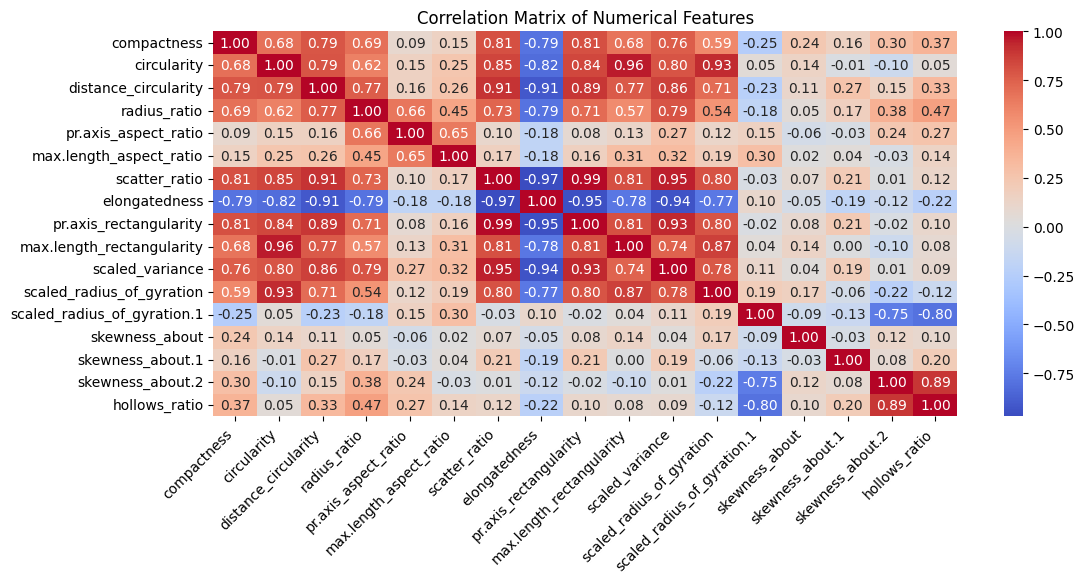

In [244]:
#select only numerical columns for correlation matrix
numerical_df=df.select_dtypes(include=[np.number])

#calculate te correlation matrix
correlation_matrix=numerical_df.corr()

#plot the correlation heatmap
plt.figure(figsize=(12,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.title("Correlation Matrix of Numerical Features")
plt.show()

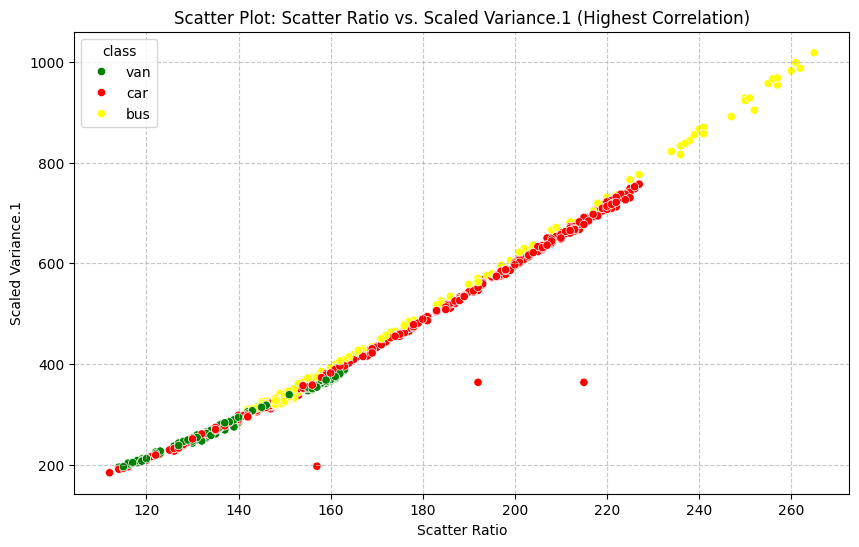

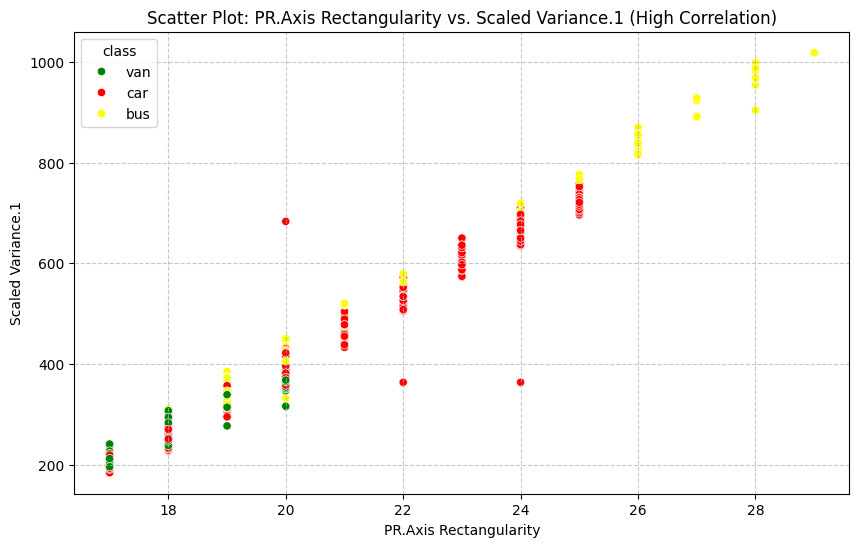

In [198]:
#Visualizing Highly Correlated Features
custom_palette = {'car': 'red', 'van': 'green', 'bus': 'yellow'}

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='scatter_ratio', y='scaled_variance.1', hue='class', palette=custom_palette)
plt.title('Scatter Plot: Scatter Ratio vs. Scaled Variance.1 (Highest Correlation)')
plt.xlabel('Scatter Ratio')
plt.ylabel('Scaled Variance.1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pr.axis_rectangularity', y='scaled_variance.1', hue='class', palette=custom_palette)
plt.title('Scatter Plot: PR.Axis Rectangularity vs. Scaled Variance.1 (High Correlation)')
plt.xlabel('PR.Axis Rectangularity')
plt.ylabel('Scaled Variance.1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Conclusions from Highly Correlated Features:

*   **Strong Linear Trend:** As seen in the plots (e.g., 'scatter_ratio' vs. 'scaled_variance.1'), highly correlated features tend to follow a clear linear pattern. When one feature increases, the other tends to increase (positive correlation) or decrease (negative correlation) predictably.
*   **Redundancy:** Features with very high correlation might be measuring similar aspects of the data. In modeling tasks, one of these highly correlated features could potentially be removed to reduce dimensionality without significant loss of information, especially if multicollinearity is a concern.
*   **Classification Insights:** The separation of 'class' groups (car, bus, van) might be more distinct along the direction of this strong linear trend, suggesting these correlated features are good indicators for differentiating vehicle types.

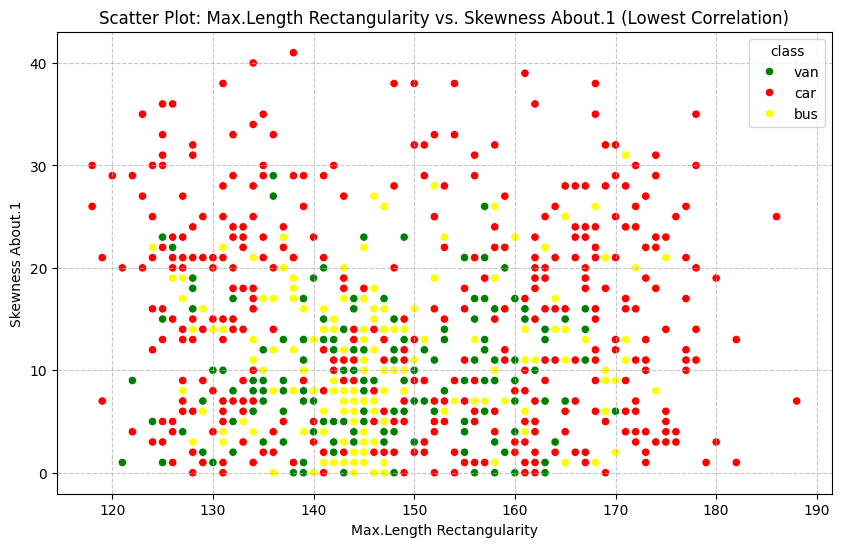

In [199]:
#Visualizing Weakly Correlated Features
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='max.length_rectangularity', y='skewness_about.1', hue='class', palette=custom_palette)
plt.title('Scatter Plot: Max.Length Rectangularity vs. Skewness About.1 (Lowest Correlation)')
plt.xlabel('Max.Length Rectangularity')
plt.ylabel('Skewness About.1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

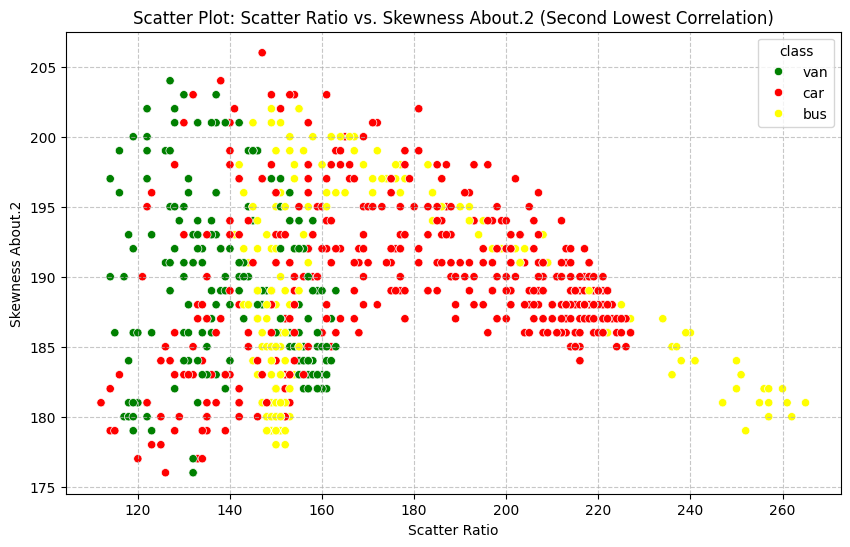

In [200]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='scatter_ratio', y='skewness_about.2', hue='class', palette=custom_palette)
plt.title('Scatter Plot: Scatter Ratio vs. Skewness About.2 (Second Lowest Correlation)')
plt.xlabel('Scatter Ratio')
plt.ylabel('Skewness About.2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Removing a Highly Correlated Column

To address multicollinearity and simplify the dataset, we will remove one of the features from the pair with the highest correlation. We've identified `scatter_ratio` and `scaled_variance.1` as having the highest correlation (0.996). We will remove `scaled_variance.1`.

In [201]:
import numpy as np

# Assuming correlation_matrix is already calculated and available from previous steps
# If not, it should be re-calculated:
# numerical_df = df.select_dtypes(include=[np.number])
# correlation_matrix = numerical_df.corr()

# Find the highest correlated pair excluding self-correlation
# Create a mask to set the upper triangle and diagonal to NaN to avoid duplicates and self-correlation
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
corr_matrix_masked = correlation_matrix.mask(mask)

# Get the absolute values to find the strongest correlation, whether positive or negative
highest_corr = corr_matrix_masked.abs().unstack().sort_values(ascending=False)

# Filter out NaN values and get the first (highest) correlation pair
highest_corr_pairs = highest_corr.drop_duplicates().dropna().iloc[[0]]

# Identify the column to drop (the second one in the highest correlated pair)
# The key from the unstacked series is a tuple (column1, column2)
column_to_drop = highest_corr_pairs.index[0][1]

# Drop the identified column from the DataFrame
df = df.drop(columns=[column_to_drop])

print(f"Column '{column_to_drop}' has been successfully removed from the DataFrame.")
print("New DataFrame shape:", df.shape)

Column 'scaled_variance.1' has been successfully removed from the DataFrame.
New DataFrame shape: (846, 18)


In [202]:
df

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,188.0,127.0,9.0,11.0,180.0,183,bus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93,39.0,87.0,183.0,64.0,8,169.0,40.0,20.0,134,200.0,149.0,72.0,7.0,25.0,188.0,195,car
842,89,46.0,84.0,163.0,66.0,11,159.0,43.0,20.0,159,173.0,176.0,72.0,1.0,20.0,186.0,197,van
843,106,54.0,101.0,222.0,67.0,12,222.0,30.0,25.0,173,228.0,200.0,70.0,3.0,4.0,187.0,201,car
844,86,36.0,78.0,146.0,58.0,7,135.0,50.0,18.0,124,155.0,148.0,66.0,0.0,25.0,190.0,195,car


### Displaying Actual Outlier Values for Remaining Columns

Now, let's identify and display the specific outlier values for each of the columns that still contain them, based on the Interquartile Range (IQR) method and the current state of our DataFrame.

In [203]:
# Displaying Actual Outlier Values for Remaining Columns
import pandas as pd

# Select only numerical columns for outlier detection from the CURRENT df
numerical_cols = df.select_dtypes(include=[np.number]).columns

outlier_values_data = []
columns_with_new_outliers = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outliers.empty:
        columns_with_new_outliers.append(col)
        print(f"\n--- Outliers for feature: {col} ---")
        display(outliers[['class', col]])

if not columns_with_new_outliers:
    print("No columns found with outliers based on the IQR method in the current DataFrame.")


--- Outliers for feature: radius_ratio ---


,class,radius_ratio
37,van,306.0
135,van,322.0
388,van,333.0



--- Outliers for feature: pr.axis_aspect_ratio ---


,class,pr.axis_aspect_ratio
4,bus,103.0
37,van,126.0
100,bus,126.0
135,van,133.0
291,van,102.0
388,van,138.0
523,van,97.0
706,van,105.0



--- Outliers for feature: max.length_aspect_ratio ---


...

,class,scaled_radius_of_gyration.1
4,bus,127.0
37,van,118.0
47,bus,88.0
79,bus,88.0
100,bus,119.0
135,van,97.0
230,van,89.0
291,van,90.0
381,bus,88.0
388,van,135.0



--- Outliers for feature: skewness_about ---


,class,skewness_about
44,car,20.0
113,car,21.0
123,car,22.0
190,car,20.0
346,car,21.0
400,car,21.0
505,car,21.0
516,car,22.0
623,car,22.0
761,car,22.0



--- Outliers for feature: skewness_about.1 ---


,class,skewness_about.1
132,car,41.0


# Checking the Relationship between Outliers and the Target Variable ('class')

To understand how outliers are distributed by vehicle class, we will visualize box plots for each column with outliers, separating the data by the variable 'class'.

Generate box plots for columns with outliers, grouped by 'class':


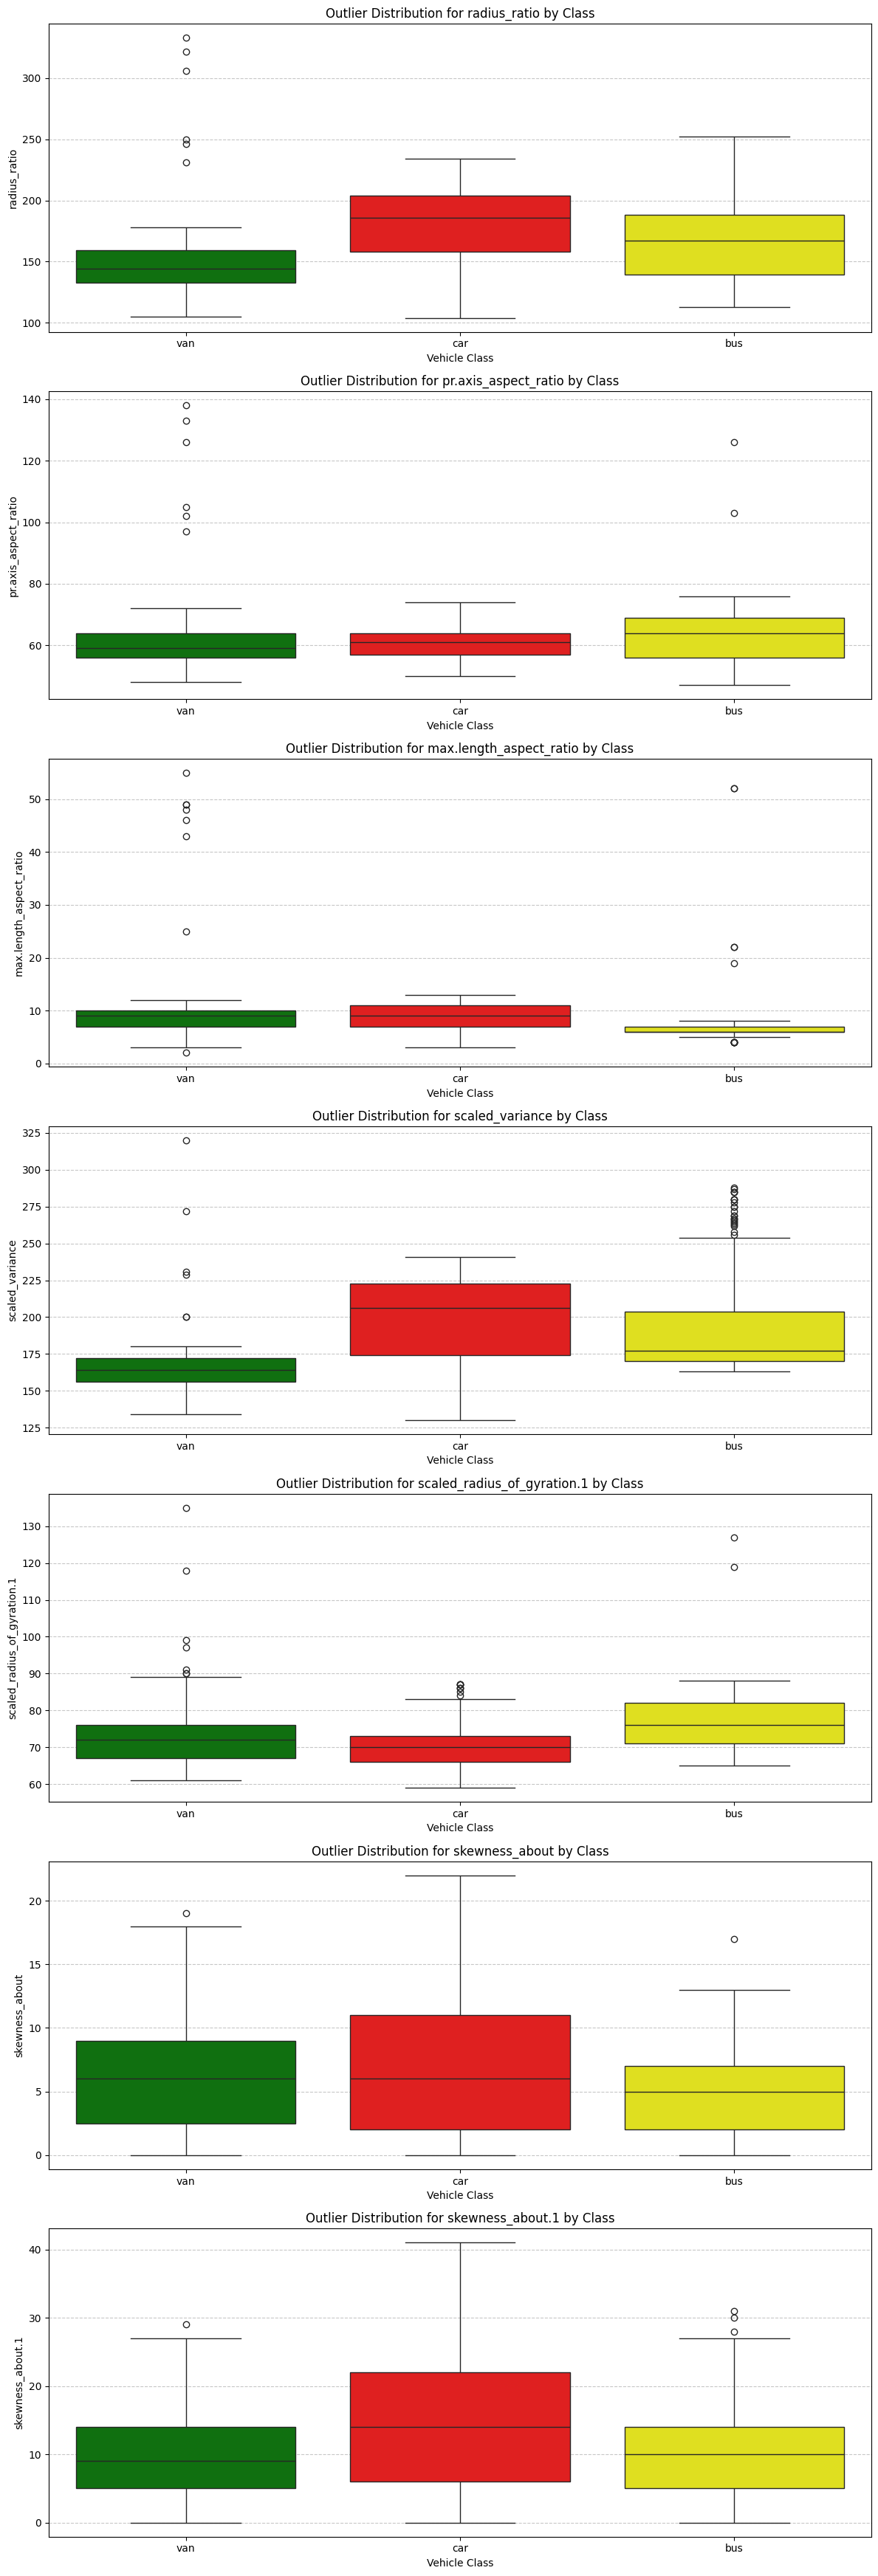

In [204]:
if 'columns_with_new_outliers' in locals() and columns_with_new_outliers:
    print("Generate box plots for columns with outliers, grouped by 'class':")
    plt.figure(figsize=(12, 5 * len(columns_with_new_outliers)))
    for i, col in enumerate(columns_with_new_outliers):
        plt.subplot(len(columns_with_new_outliers), 1, i + 1)
        sns.boxplot(x='class', y=col, data=df, palette=custom_palette, hue='class', legend=False)
        plt.title(f'Outlier Distribution for {col} by Class')
        plt.xlabel('Vehicle Class')
        plt.ylabel(col)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No outlier columns were identified to view the class distribution.")

In [205]:
print(columns_with_new_outliers)

['radius_ratio', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scaled_variance', 'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1']


*Constant presence of outliers* in a certain class for a certain characteristic can be a distinctive feature of that class, not necessarily a data error.

**-note:** *'van'* consistently shows outliers for *radius_ratio* feature.

    This observation suggests that these "outliers" might not be mistakes or anomalies in the data, but rather inherent characteristics that define that specific vehicle class.

    If vans frequently have radius_ratio values that are considered outliers compared to the overall dataset, it could mean that vans, by their very nature, tend to have a wider range or extreme values for radius_ratio than cars or buses. These values are distinctive of the 'van' class.

# When outliers are distinctive features of a class, blindly removing them can lead to a loss of valuable information that helps differentiate between classes.

## Model Training and Evaluation (Without Outlier Treatment)

First, we will train a Random Forest Classifier on the dataset without any explicit outlier treatment and evaluate its performance. This will serve as our baseline for comparison.

In [206]:
X = df[['compactness', 'circularity', 'distance_circularity','radius_ratio', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_radius_of_gyration', 'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1', 'skewness_about.2', 'hollows_ratio']]
y = df['class']

In [207]:
#X = df.drop('class', axis=1)
#y = df['class']

In [208]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Ensure X and y are defined from previous steps (P0REFx3Wo-uc)
X = df[['compactness', 'circularity', 'distance_circularity','radius_ratio', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_radius_of_gyration', 'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1', 'skewness_about.2', 'hollows_ratio']]
y = df['class']

# Encode the target variable 'class' (from u6KgkIWrnqSq)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and testing sets (from gtQXxj72njpi)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale numerical features (from C0BLTKshndop)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with column names (from 9_ReNPG2nLqg)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

model = RandomForestClassifier(random_state=42)

# Fit the model on the scaled training data
model.fit(X_train_scaled_df, y_train)

RandomForestClassifier(random_state=42)

In [209]:
# Encode the target variable 'class'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [210]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [211]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [212]:
# Convert scaled arrays back to DataFrames with column names for clarity (optional, but good for inspection)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [213]:
X_train_scaled_df

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,-0.443190,0.349898,0.182642,-0.252763,0.249020,0.252818,-0.169670,0.129128,-0.213492,0.818422,-0.360671,0.331933,0.086293,0.522964,-1.434963,-0.644109,-0.124558
1,1.008227,1.156070,1.206724,1.274414,0.249020,0.252818,1.058019,-1.033025,0.972702,0.614846,0.837350,0.362851,-0.949610,-1.296198,0.690099,0.629508,0.954946
2,1.371081,1.317305,1.654760,1.068832,0.129036,0.650734,1.641171,-1.291281,1.763498,1.361293,1.225897,0.826620,-0.172682,1.735739,2.479625,-0.007301,0.954946
3,2.580596,1.156070,1.142719,0.980726,0.009052,0.252818,1.487710,-1.291281,1.368100,1.157716,1.323034,1.228553,-0.043195,1.533610,-0.987581,-0.166503,0.145318
4,1.854887,1.639774,0.886699,0.628301,-0.590867,-0.543014,2.224324,-1.678665,2.158896,1.497011,2.553433,2.094254,1.640148,0.320835,-0.428354,-0.803312,-1.608876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,0.403470,2.284712,1.654760,1.685577,0.968922,0.451776,1.702556,-1.420409,1.763498,2.582753,1.193518,1.352224,-0.302170,0.725093,1.361171,-0.484907,0.280256
672,0.645373,0.188663,1.462745,1.156939,0.249020,0.451776,0.873866,-0.903897,0.972702,0.275551,0.772592,-0.471933,-0.949610,-1.296198,2.255934,0.788710,1.224822
673,-1.410802,0.027429,-0.905446,-0.575819,0.848938,-0.741973,-0.630053,0.516512,-0.608889,-0.267320,-0.619702,0.301015,0.992708,-0.285552,-1.434963,-1.280918,-1.608876
674,-1.047948,-1.262447,-0.905446,-0.722663,-0.230915,-0.543014,-1.182513,1.291281,-1.004287,-1.217344,-1.234902,-1.646813,-0.949610,-0.689810,0.130872,0.947912,0.954946


In [214]:
y_train_scaled_df = pd.DataFrame(y_train, columns=['class'])
y_train

array([2, 1, 1, 1, 0, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 0,
       1, 1, 2, 1, 0, 2, 1, 1, 1, 2, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       2, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 2, 1, 2, 1, 2, 0, 2,
       2, 1, 1, 0, 2, 0, 0, 0, 0, 2, 1, 1, 1, 0, 0, 1, 1, 2, 1, 1, 1, 1,
       0, 1, 2, 1, 1, 1, 1, 1, 0, 1, 2, 2, 0, 1, 1, 2, 1, 2, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 2, 2, 2, 1, 1, 1, 0, 1, 1, 2, 1, 0, 2, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1, 2, 0, 2, 1, 2, 1, 0, 2, 1, 1,
       2, 1, 1, 1, 2, 2, 0, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 0, 1, 2, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 2, 1, 1, 0, 0, 1, 1, 1, 2, 1, 1,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 1, 2, 2, 1, 0, 1, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 2, 0, 0, 0, 1, 1, 2, 2, 1, 1, 2, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 2, 2, 1, 0, 2, 1, 1, 1, 2, 1, 0, 1, 2, 1, 1, 0, 1,
       1, 2, 1, 0, 1, 1, 0, 2, 2, 1, 2, 2, 0, 0, 1, 1, 2, 2, 1, 2, 0, 0,
       2, 0, 2, 2, 2, 2, 0, 0, 1, 2, 1, 0, 1, 0, 0,

In [215]:
predictions = model.predict(X_test_scaled_df)
predictions = np.round(predictions)
predictions

array([0, 2, 0, 1, 0, 2, 2, 1, 0, 1, 1, 0, 2, 1, 1, 1, 1, 0, 1, 1, 2, 2,
       1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 0, 2, 2, 0, 0, 1, 0, 1, 2, 0, 1, 2,
       1, 1, 0, 2, 0, 2, 0, 0, 1, 2, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 2, 2, 1, 1, 1, 2, 0, 2, 1, 1, 1, 1, 2, 0,
       2, 1, 1, 1, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 1, 2, 1, 1,
       2, 0, 2, 0, 0, 2, 0, 1, 0, 1, 0, 1, 1, 2, 0, 1, 0, 2, 0, 1, 0, 2,
       0, 1, 0, 0, 0, 1, 1, 0, 2, 1, 0, 0, 2, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       2, 2, 0, 2, 1, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 2])

In [216]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [217]:
# Initialize and train the Random Forest Classifier
rf_model_baseline = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_baseline.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_baseline = rf_model_baseline.predict(X_test_scaled)
y_prob_baseline = rf_model_baseline.predict_proba(X_test_scaled)

# Evaluate the model
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
report_baseline = classification_report(y_test, y_pred_baseline, target_names=le.classes_)
conf_matrix_baseline = confusion_matrix(y_test, y_pred_baseline)

print("--- Random Forest Model Performance (Without Outlier Treatment) ---")
print(f"Accuracy: {accuracy_baseline:.4f}")
print("\nClassification Report:")
print(report_baseline)
print("\nConfusion Matrix:")
print(conf_matrix_baseline)

# Calculate ROC AUC for each class (one-vs-rest)
roc_auc_scores_baseline = []
for i in range(len(le.classes_)):
    roc_auc_scores_baseline.append(roc_auc_score(y_test == i, y_prob_baseline[:, i]))

print("\nROC AUC per class:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {roc_auc_scores_baseline[i]:.4f}")

# Store results for comparison
results_baseline = {
    'Accuracy': accuracy_baseline,
    'Classification Report': report_baseline,
    'Confusion Matrix': conf_matrix_baseline,
    'ROC AUC per class': dict(zip(le.classes_, roc_auc_scores_baseline))
}

--- Random Forest Model Performance (Without Outlier Treatment) ---
Accuracy: 0.9706

Classification Report:
              precision    recall  f1-score   support

         bus       1.00      0.98      0.99        52
         car       0.97      0.96      0.97        78
         van       0.93      0.97      0.95        40

    accuracy                           0.97       170
   macro avg       0.97      0.97      0.97       170
weighted avg       0.97      0.97      0.97       170


Confusion Matrix:
[[51  1  0]
 [ 0 75  3]
 [ 0  1 39]]

ROC AUC per class:
  bus: 0.9993
  car: 0.9964
  van: 0.9954


## Outlier Treatment (Winsorization) and Model Training

Next, we will apply Winsorization (capping) to the identified outlier columns. We'll create a new DataFrame with treated outliers and then train and evaluate another Random Forest model on this treated data.

In [218]:
# Create a copy of the DataFrame for outlier treatment
df_treated = df.copy()

# Apply Winsorization to columns identified with outliers
# We will cap values at the 5th and 95th percentiles (common practice for Winsorization)
for col in columns_with_new_outliers:
    lower_bound = df_treated[col].quantile(0.05)
    upper_bound = df_treated[col].quantile(0.95)
    df_treated[col] = df_treated[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers treated using Winsorization.")

# Separate features (X_treated) and target (y) from the treated DataFrame
X_treated = df_treated.drop('class', axis=1)
y_treated = df_treated['class'] # Target remains the same

# Encode the target variable 'class' (already done, but re-applying to treated y for consistency)
y_treated_encoded = le.transform(y_treated)

# Split treated data into training and testing sets
X_train_treated, X_test_treated, y_train_treated, y_test_treated = train_test_split(X_treated, y_treated_encoded, test_size=0.2, random_state=42)

# Scale numerical features of the treated data
# Initialize a new scaler to avoid data leakage from the baseline model's fit
scaler_treated = StandardScaler()
X_train_treated_scaled = scaler_treated.fit_transform(X_train_treated)
X_test_treated_scaled = scaler_treated.transform(X_test_treated)

print("Data preparation complete for model with outlier treatment.")

Outliers treated using Winsorization.
Data preparation complete for model with outlier treatment.


In [219]:
# Initialize and train the Random Forest Classifier on treated data
rf_model_treated = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_treated.fit(X_train_treated_scaled, y_train_treated)

# Make predictions on the test set of treated data
y_pred_treated = rf_model_treated.predict(X_test_treated_scaled)
y_prob_treated = rf_model_treated.predict_proba(X_test_treated_scaled)

# Evaluate the model
accuracy_treated = accuracy_score(y_test_treated, y_pred_treated)
report_treated = classification_report(y_test_treated, y_pred_treated, target_names=le.classes_)
conf_matrix_treated = confusion_matrix(y_test_treated, y_pred_treated)

print("--- Random Forest Model Performance (With Outlier Treatment) ---")
print(f"Accuracy: {accuracy_treated:.4f}")
print("\nClassification Report:")
print(report_treated)
print("\nConfusion Matrix:")
print(conf_matrix_treated)

# Calculate ROC AUC for each class (one-vs-rest)
roc_auc_scores_treated = []
for i in range(len(le.classes_)):
    roc_auc_scores_treated.append(roc_auc_score(y_test_treated == i, y_prob_treated[:, i]))

print("\nROC AUC per class:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {roc_auc_scores_treated[i]:.4f}")

# Store results for comparison
results_treated = {
    'Accuracy': accuracy_treated,
    'Classification Report': report_treated,
    'Confusion Matrix': conf_matrix_treated,
    'ROC AUC per class': dict(zip(le.classes_, roc_auc_scores_treated))
}

--- Random Forest Model Performance (With Outlier Treatment) ---
Accuracy: 0.9647

Classification Report:
              precision    recall  f1-score   support

         bus       1.00      0.98      0.99        52
         car       0.97      0.95      0.96        78
         van       0.91      0.97      0.94        40

    accuracy                           0.96       170
   macro avg       0.96      0.97      0.96       170
weighted avg       0.97      0.96      0.96       170


Confusion Matrix:
[[51  1  0]
 [ 0 74  4]
 [ 0  1 39]]

ROC AUC per class:
  bus: 0.9993
  car: 0.9971
  van: 0.9961


## **Cross-Validation for Random Forest (Baseline) Model**
To evaluate the stability and generalization performance of the baseline Random Forest model, we will perform K-Fold Cross-Validation. We will use cross_validate to calculate accuracy and F1-score across 5 folds.

In [220]:
from sklearn.model_selection import cross_validate

# Define the scoring metrics for cross-validation
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}

# Perform cross-validation
cv_results = cross_validate(rf_model_baseline, X_train_scaled, y_train, cv=5, scoring=scoring, return_train_score=False)

print("--- Cross-Validation Results for Random Forest (Baseline) ---")
print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"Mean F1-score (macro): {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")

print("\nIndividual fold accuracies:")
for i, score in enumerate(cv_results['test_accuracy']):
    print(f"  Fold {i+1} Accuracy: {score:.4f}")

print("\nIndividual fold F1-scores (macro):")
for i, score in enumerate(cv_results['test_f1_macro']):
    print(f"  Fold {i+1} F1-score (macro): {score:.4f}")

--- Cross-Validation Results for Random Forest (Baseline) ---
Mean Accuracy: 0.9586 (+/- 0.0246)
Mean F1-score (macro): 0.9559 (+/- 0.0264)

Individual fold accuracies:
  Fold 1 Accuracy: 0.9632
  Fold 2 Accuracy: 0.9778
  Fold 3 Accuracy: 0.9111
  Fold 4 Accuracy: 0.9630
  Fold 5 Accuracy: 0.9778

Individual fold F1-scores (macro):
  Fold 1 F1-score (macro): 0.9569
  Fold 2 F1-score (macro): 0.9774
  Fold 3 F1-score (macro): 0.9056
  Fold 4 F1-score (macro): 0.9624
  Fold 5 F1-score (macro): 0.9772


## Comparison of Random Forest Models

Let's compare the performance metrics of the Random Forest model trained *without* outlier treatment against the one trained *with* outlier treatment (Winsorization).

In [221]:
print("### Performance Comparison ###")
print("\n--- Model Without Outlier Treatment ---")
print(f"Accuracy: {results_baseline['Accuracy']:.4f}")
print("ROC AUC per class:")
for class_name, score in results_baseline['ROC AUC per class'].items():
    print(f"  {class_name}: {score:.4f}")

print("\n--- Model With Outlier Treatment (Winsorization) ---")
print(f"Accuracy: {results_treated['Accuracy']:.4f}")
print("ROC AUC per class:")
for class_name, score in results_treated['ROC AUC per class'].items():
    print(f"  {class_name}: {score:.4f}")

print("\nBased on these metrics, you can observe whether outlier treatment improved, worsened, or had a negligible effect on the model's performance.")

### Performance Comparison ###

--- Model Without Outlier Treatment ---
Accuracy: 0.9706
ROC AUC per class:
  bus: 0.9993
  car: 0.9964
  van: 0.9954

--- Model With Outlier Treatment (Winsorization) ---
Accuracy: 0.9647
ROC AUC per class:
  bus: 0.9993
  car: 0.9971
  van: 0.9961

Based on these metrics, you can observe whether outlier treatment improved, worsened, or had a negligible effect on the model's performance.


## F1-Score Comparison per Class

The F1-score provides a balanced measure of precision and recall, and it's particularly useful for imbalanced datasets or when you want to evaluate a model's performance on a per-class basis.

In [222]:
from sklearn.metrics import classification_report

# Convert classification reports (strings) to dictionaries for easier access to F1-scores
report_dict_baseline = classification_report(y_test, y_pred_baseline, target_names=le.classes_, output_dict=True)
report_dict_treated = classification_report(y_test_treated, y_pred_treated, target_names=le.classes_, output_dict=True)

print("### F1-Score Comparison per Class ###")

print("\n--- Model Without Outlier Treatment ---")
for class_name in le.classes_:
    f1_score_baseline = report_dict_baseline[class_name]['f1-score']
    print(f"  F1-score for {class_name}: {f1_score_baseline:.4f}")

print("\n--- Model With Outlier Treatment (Winsorization) ---")
for class_name in le.classes_:
    f1_score_treated = report_dict_treated[class_name]['f1-score']
    print(f"  F1-score for {class_name}: {f1_score_treated:.4f}")

print("\nThis detailed breakdown allows you to see how each model performs for each specific vehicle class.")

### F1-Score Comparison per Class ###

--- Model Without Outlier Treatment ---
  F1-score for bus: 0.9903
  F1-score for car: 0.9677
  F1-score for van: 0.9512

--- Model With Outlier Treatment (Winsorization) ---
  F1-score for bus: 0.9903
  F1-score for car: 0.9610
  F1-score for van: 0.9398

This detailed breakdown allows you to see how each model performs for each specific vehicle class.


# Viewing the Confusion Matrix

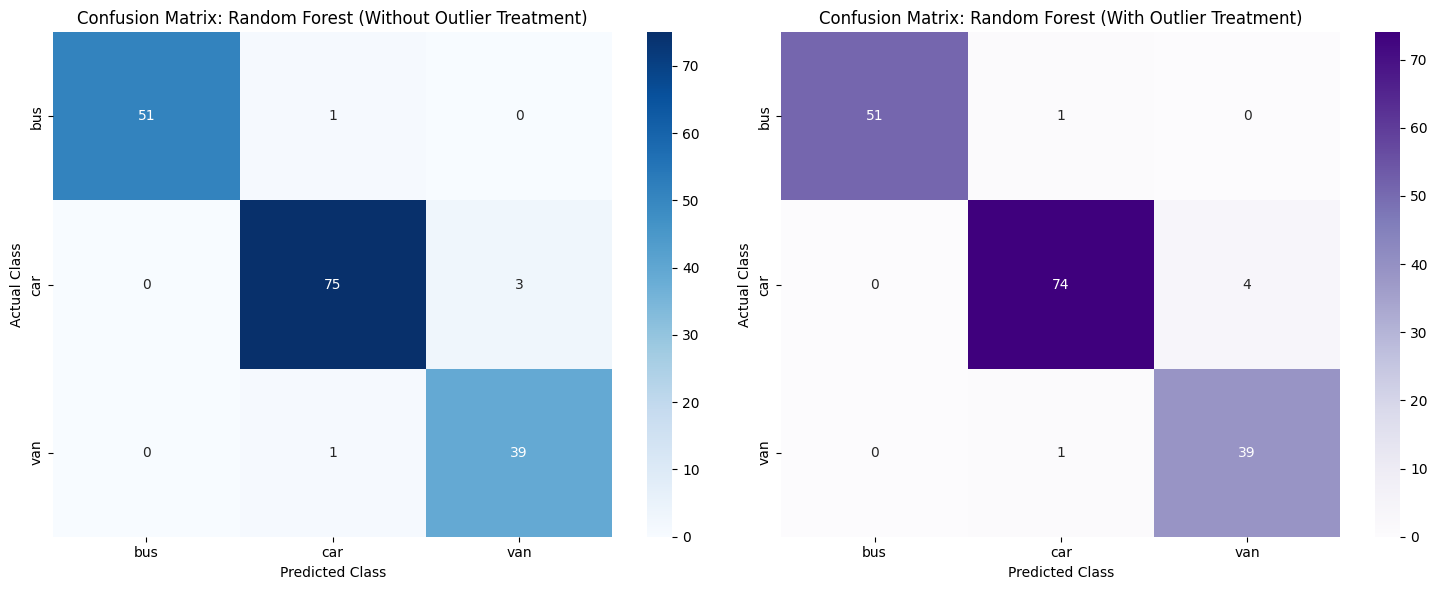

In [223]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.heatmap(conf_matrix_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Random Forest (Without Outlier Treatment)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.heatmap(conf_matrix_treated, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Random Forest (With Outlier Treatment)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

## Model Training and Evaluation (Logistic Regression)

We will now train and evaluate a Logistic Regression model on the same scaled dataset used for the basic Random Forest model (without treating outliers). This will allow us to compare the performance of a linear model with that of a tree-based model.

In [224]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression Classifier
# Using 'liblinear' solver for multiclass classification with L1/L2 regularization
# 'class_weight="balanced"' helps handle potential class imbalance
lr_model = LogisticRegression(solver='liblinear', random_state=42, multi_class='ovr', class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, target_names=le.classes_)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print("--- Logistic Regression Model Performance ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print("\nClassification Report:")
print(report_lr)
print("\nConfusion Matrix:")
print(conf_matrix_lr)

# Calculate ROC AUC for each class (one-vs-rest)
roc_auc_scores_lr = []
for i in range(len(le.classes_)):
    roc_auc_scores_lr.append(roc_auc_score(y_test == i, y_prob_lr[:, i]))

print("\nROC AUC per class:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {roc_auc_scores_lr[i]:.4f}")

# Store results for comparison
results_lr = {
    'Accuracy': accuracy_lr,
    'Classification Report': report_lr,
    'Confusion Matrix': conf_matrix_lr,
    'ROC AUC per class': dict(zip(le.classes_, roc_auc_scores_lr))
}

--- Logistic Regression Model Performance ---
Accuracy: 0.9235

Classification Report:
              precision    recall  f1-score   support

         bus       0.90      0.90      0.90        52
         car       0.96      0.90      0.93        78
         van       0.89      1.00      0.94        40

    accuracy                           0.92       170
   macro avg       0.92      0.93      0.92       170
weighted avg       0.93      0.92      0.92       170


Confusion Matrix:
[[47  3  2]
 [ 5 70  3]
 [ 0  0 40]]

ROC AUC per class:
  bus: 0.9814
  car: 0.9760
  van: 0.9987


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


# Comparing the Random Forest Model to Logistic Regression
Now we will directly compare the performance metrics of the Random Forest model (baseline) with those of the Logistic Regression model.

In [225]:
print("### Model Performance Comparison ###")

print("\n--- Random Forest Model (Without Outlier Treatment) ---")
print(f"Accuracy: {results_baseline['Accuracy']:.4f}")
print("ROC AUC per class:")
for class_name, score in results_baseline['ROC AUC per class'].items():
    print(f"  {class_name}: {score:.4f}")
report_dict_baseline = classification_report(y_test, y_pred_baseline, target_names=le.classes_, output_dict=True)
print("F1-score per class:")
for class_name in le.classes_:
    f1_score_baseline = report_dict_baseline[class_name]['f1-score']
    print(f"  {class_name}: {f1_score_baseline:.4f}")
print("Confusion Matrix:\n", conf_matrix_baseline)

print("\n--- Logistic Regression Model ---")
print(f"Accuracy: {results_lr['Accuracy']:.4f}")
print("ROC AUC per class:")
for class_name, score in results_lr['ROC AUC per class'].items():
    print(f"  {class_name}: {score:.4f}")
report_dict_lr = classification_report(y_test, y_pred_lr, target_names=le.classes_, output_dict=True)
print("F1-score per class:")
for class_name in le.classes_:
    f1_score_lr = report_dict_lr[class_name]['f1-score']
    print(f"  {class_name}: {f1_score_lr:.4f}")
print("Confusion Matrix:\n", conf_matrix_lr)

print("\nAnalyze these metrics to understand the performance differences between the two types of models.")

### Model Performance Comparison ###

--- Random Forest Model (Without Outlier Treatment) ---
Accuracy: 0.9706
ROC AUC per class:
  bus: 0.9993
  car: 0.9964
  van: 0.9954
F1-score per class:
  bus: 0.9903
  car: 0.9677
  van: 0.9512
Confusion Matrix:
 [[51  1  0]
 [ 0 75  3]
 [ 0  1 39]]

--- Logistic Regression Model ---
Accuracy: 0.9235
ROC AUC per class:
  bus: 0.9814
  car: 0.9760
  van: 0.9987
F1-score per class:
  bus: 0.9038
  car: 0.9272
  van: 0.9412
Confusion Matrix:
 [[47  3  2]
 [ 5 70  3]
 [ 0  0 40]]

Analyze these metrics to understand the performance differences between the two types of models.


# Visualize key metrics for Model Comparison.

In [226]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for comparison
model_names = ['Random Forest (Baseline)', 'Logistic Regression']
accuracies = [results_baseline['Accuracy'], results_lr['Accuracy']]

# Extract F1-scores per class
f1_scores_baseline = [report_dict_baseline[cls]['f1-score'] for cls in le.classes_]
f1_scores_lr = [report_dict_lr[cls]['f1-score'] for cls in le.classes_]

# Create DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
})

# Add F1-scores for each class to the DataFrame
for i, cls in enumerate(le.classes_):
    comparison_df[f'F1-score {cls}'] = [f1_scores_baseline[i], f1_scores_lr[i]]

# Extract ROC AUC scores per class
roc_auc_baseline = list(results_baseline['ROC AUC per class'].values())
roc_auc_lr = list(results_lr['ROC AUC per class'].values())

for i, cls in enumerate(le.classes_):
    comparison_df[f'ROC AUC {cls}'] = [roc_auc_baseline[i], roc_auc_lr[i]]

print("Comparative Metrics:")
display(comparison_df)


Comparative Metrics:


,Model,Accuracy,F1-score bus,F1-score car,F1-score van,ROC AUC bus,ROC AUC car,ROC AUC van
0,Random Forest (Baseline),0.970588,0.990291,0.967742,0.951220,0.999267,0.996377,0.995385
1,Logistic Regression,0.923529,0.903846,0.927152,0.941176,0.981421,0.976031,0.998654


Accuracy Comparison

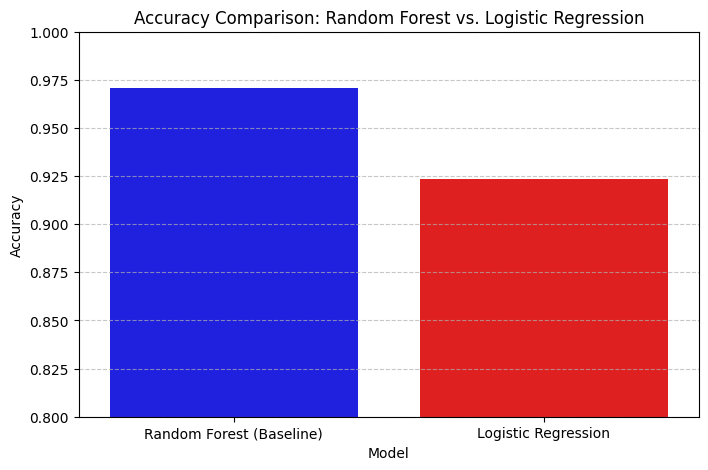

In [227]:
fig = plt.figure(figsize=(8, 5))
custom_model_palette = {'Random Forest (Baseline)': 'blue', 'Logistic Regression': 'red'}
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette=custom_model_palette, hue='Model', legend=False)
plt.title('Accuracy Comparison: Random Forest vs. Logistic Regression')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0) # Set y-axis limits for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Comparisone F1-Score per Class

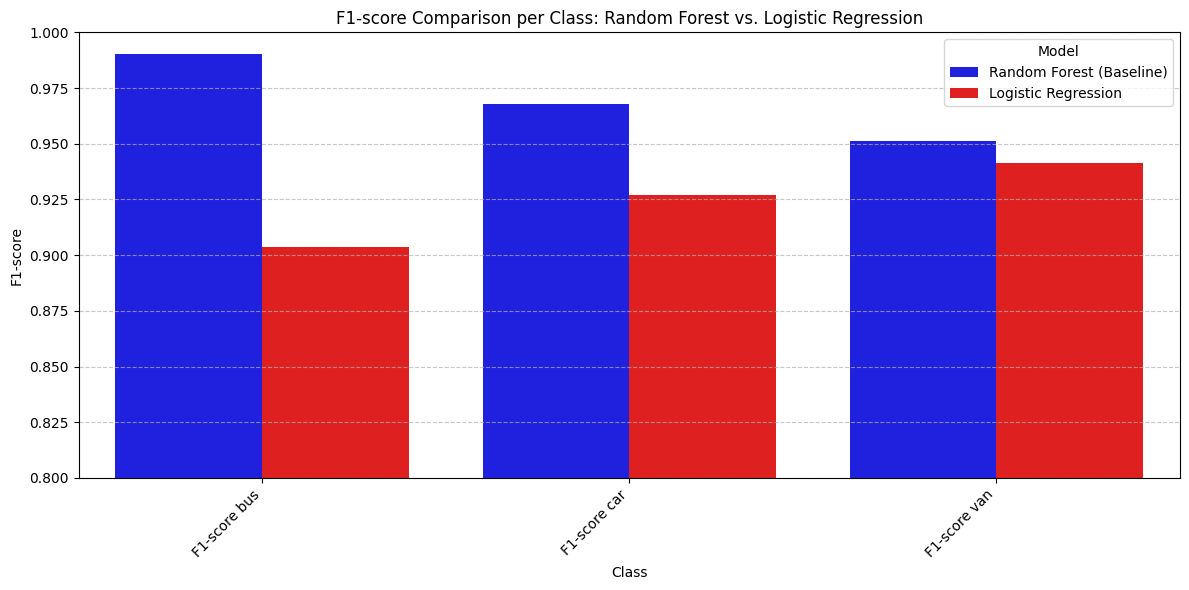

In [228]:
fig = plt.figure(figsize=(12, 6))

f1_df = comparison_df[['Model'] + [f'F1-score {cls}' for cls in le.classes_]].melt(id_vars='Model', var_name='Metric', value_name='F1-score')
custom_model_palette = {'Random Forest (Baseline)': 'blue', 'Logistic Regression': 'red'}
sns.barplot(x='Metric', y='F1-score', hue='Model', data=f1_df, palette=custom_model_palette)
plt.title('F1-score Comparison per Class: Random Forest vs. Logistic Regression')
plt.ylabel('F1-score')
plt.xlabel('Class')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparisone ROC AUC per Class

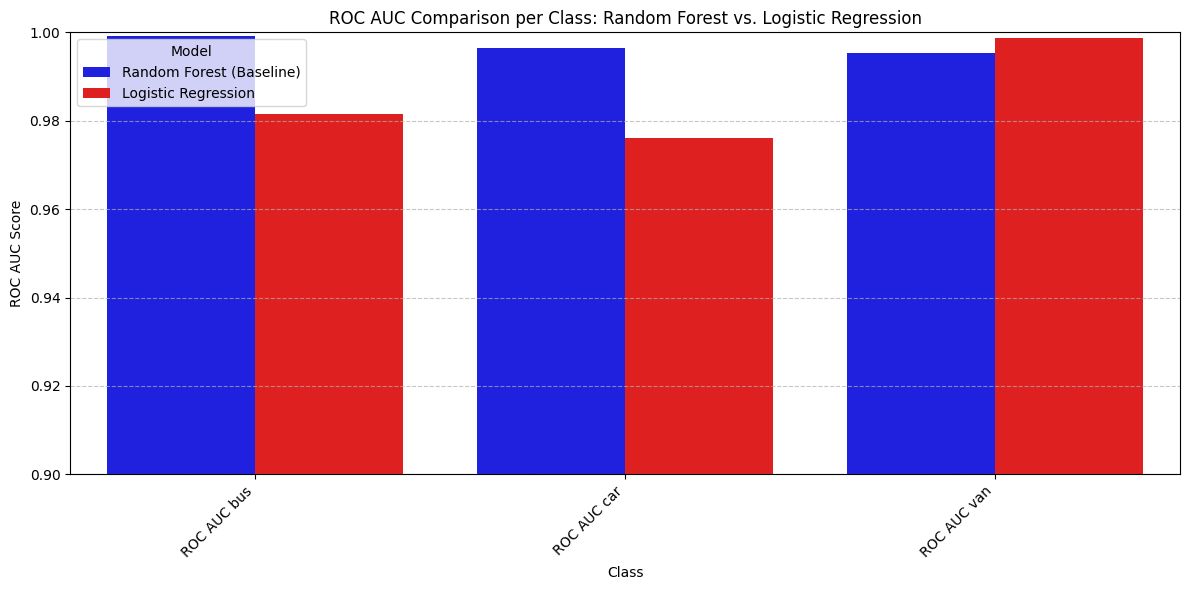

In [229]:
fig = plt.figure(figsize=(12, 6))

roc_auc_df = comparison_df[['Model'] + [f'ROC AUC {cls}' for cls in le.classes_]].melt(id_vars='Model', var_name='Metric', value_name='ROC AUC Score')
custom_model_palette = {'Random Forest (Baseline)': 'blue', 'Logistic Regression': 'red'}
sns.barplot(x='Metric', y='ROC AUC Score', hue='Model', data=roc_auc_df, palette=custom_model_palette)
plt.title('ROC AUC Comparison per Class: Random Forest vs. Logistic Regression')
plt.ylabel('ROC AUC Score')
plt.xlabel('Class')
plt.ylim(0.9, 1.0)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualizing Confusion Matrices

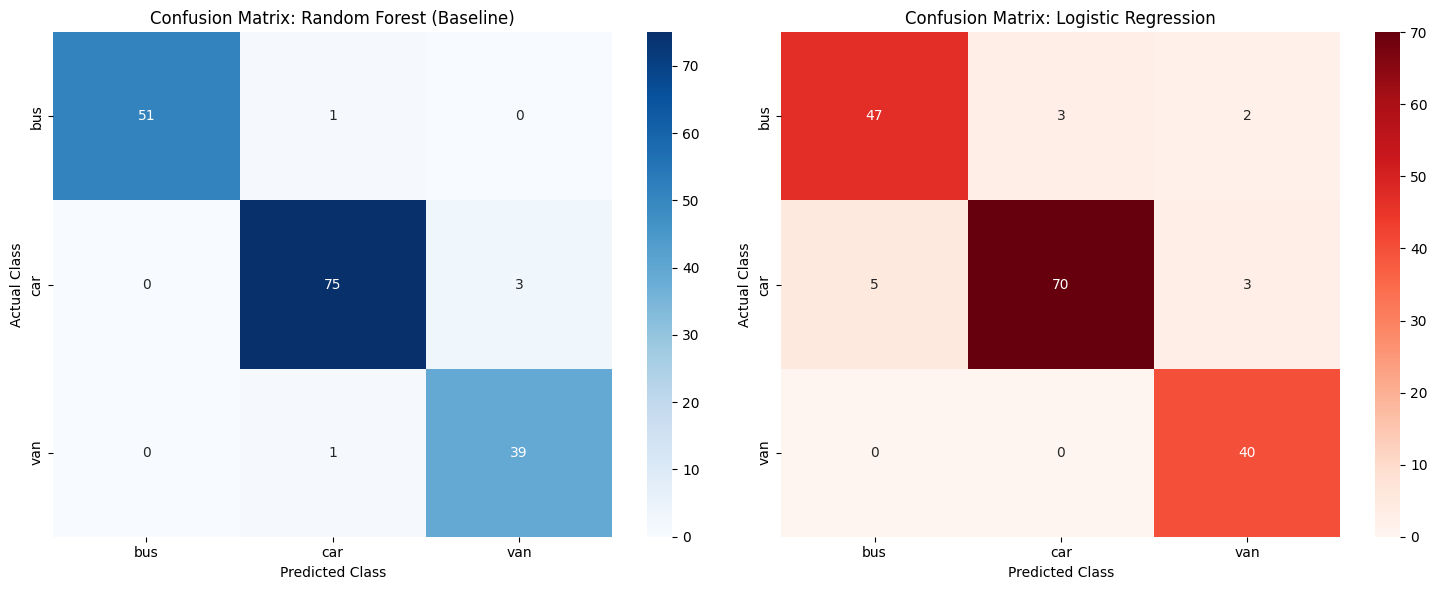

In [230]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.heatmap(conf_matrix_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Random Forest (Baseline)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

Based on the comparison of the Random Forest (baseline) and Logistic Regression models, here is a summary:

Overall Performance: The Random Forest (baseline) model generally outperformed the Logistic Regression model across most metrics.
Accuracy: The Random Forest model achieved a higher accuracy of 0.9706 compared to the Logistic Regression model's 0.9235.
F1-Score per Class: The Random Forest model showed higher F1-scores for 'bus' (0.9903) and 'car' (0.9677), while the Logistic Regression model had lower F1-scores for 'bus' (0.9038) and 'car' (0.9272). For 'van', Random Forest had 0.9512 and Logistic Regression had 0.9412.
ROC AUC per Class: Both models showed strong ROC AUC scores, with Random Forest having slightly higher or comparable scores for 'bus' (0.9993) and 'car' (0.9964) compared to Logistic Regression's 'bus' (0.9814) and 'car' (0.9760). Logistic Regression had a slightly higher ROC AUC for 'van' (0.9987) than Random Forest (0.9954).
Outlier Treatment: The Random Forest model trained with Winsorization (outlier treatment) showed a slight decrease in accuracy (0.9647) and some F1-scores compared to the baseline Random Forest, suggesting that for this dataset and model, aggressive outlier treatment was not beneficial and the model was robust to them.
In conclusion, the Random Forest (baseline) model (without explicit outlier treatment) proved to be the most effective for this classification task, demonstrating better overall predictive power

## Feature Importance for Random Forest (Baseline) Model

Let's visualize the importance of each feature in the Random Forest model to understand their contribution to the classification task.

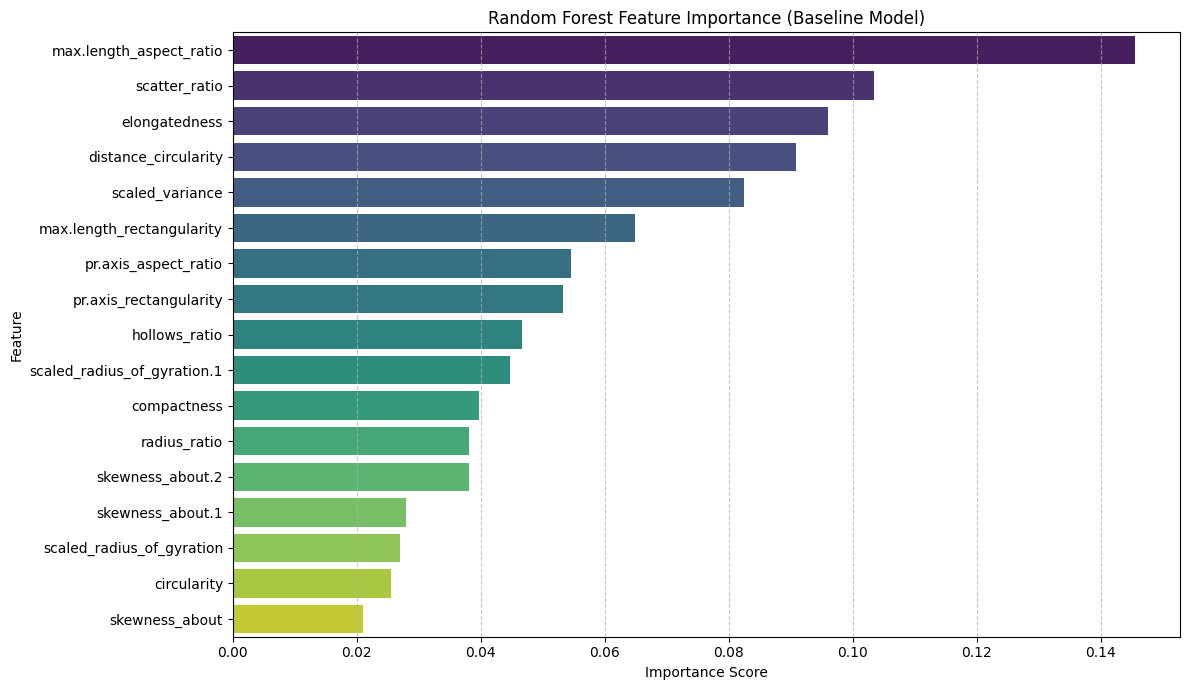

In [231]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model_baseline.feature_importances_

# Create a DataFrame to hold features and their importance scores
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance (Baseline Model)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Final Report: Vehicle Classification Model Comparison

This report summarizes the key steps taken in the vehicle classification analysis, from data preparation and exploration to the training and evaluation of different machine learning models, including the impact of outlier treatment.

## 1. Data Preparation and Cleaning

*   **Initial Data Load**: The `vehicle.csv` dataset was loaded, containing 846 entries and 19 features.
*   **Missing Values**: 41 missing values were identified across various numerical columns. These were imputed using the median of their respective columns.
*   **Feature Selection (Multicollinearity)**: An analysis of the correlation matrix revealed a very strong correlation (0.996) between `scatter_ratio` and `scaled_variance.1`. To reduce multicollinearity and simplify the model, `scaled_variance.1` was removed from the dataset.

## 2. Outlier Analysis and Treatment

*   **Outlier Detection**: Outliers were identified using the Interquartile Range (IQR) method in several numerical columns (`radius_ratio`, `pr.axis_aspect_ratio`, `max.length_aspect_ratio`, `scaled_variance`, `scaled_radius_of_gyration.1`, `skewness_about`, `skewness_about.1`).
*   **Relationship with Target Variable**: Box plots grouped by the 'class' variable showed that many identified 'outliers' were actually characteristic features of specific vehicle classes (e.g., certain `radius_ratio` values for 'van'). This suggested that these values might be discriminative rather than errors.
*   **Winsorization**: Winsorization (capping values at the 5th and 95th percentiles) was applied to the identified outlier columns to create a `df_treated` dataset.

## 3. Model Training and Evaluation

Three classification models were trained and evaluated:

### 3.1. Random Forest Classifier (Baseline - No Outlier Treatment)

*   **Training**: A Random Forest Classifier was trained on the scaled dataset without any explicit outlier treatment.
*   **Performance**:
    *   **Accuracy**: 0.9706
    *   **ROC AUC per class**: bus: 0.9993, car: 0.9964, van: 0.9954
    *   **F1-score per class**: bus: 0.9903, car: 0.9677, van: 0.9512
    *   **Confusion Matrix**: Showed excellent performance with only a few misclassifications (e.g., 1 'bus' classified as 'car', 3 'car' as 'van').

### 3.2. Random Forest Classifier (With Outlier Treatment - Winsorization)

*   **Training**: A Random Forest Classifier was trained on the scaled and Winsorized dataset.
*   **Performance**:
    *   **Accuracy**: 0.9647
    *   **ROC AUC per class**: bus: 0.9993, car: 0.9971, van: 0.9961
    *   **F1-score per class**: bus: 0.9903, car: 0.9610, van: 0.9398
*   **Comparison to Baseline**: The performance was slightly lower or comparable to the baseline model. This indicates that for the Random Forest, aggressive outlier treatment through Winsorization did not provide significant benefits and might even have removed valuable distinguishing information.

### 3.3. Logistic Regression Classifier

*   **Training**: A Logistic Regression model was trained on the same scaled dataset as the Random Forest baseline (without outlier treatment).
*   **Performance**:
    *   **Accuracy**: 0.9235
    *   **ROC AUC per class**: bus: 0.9814, car: 0.9760, van: 0.9987
    *   **F1-score per class**: bus: 0.9038, car: 0.9272, van: 0.9412
    *   **Confusion Matrix**: Showed more misclassifications compared to the Random Forest model.

## 4. Overall Model Comparison and Conclusion

| Model                        | Accuracy | F1-score bus | F1-score car | F1-score van | ROC AUC bus | ROC AUC car | ROC AUC van |
| :--------------------------- | :------- | :----------- | :----------- | :----------- | :---------- | :---------- | :---------- |
| Random Forest (Baseline)     | 0.9706   | 0.9903       | 0.9677       | 0.9512       | 0.9993      | 0.9964      | 0.9954      |
| Logistic Regression          | 0.9235   | 0.9038       | 0.9272       | 0.9412       | 0.9814      | 0.9760      | 0.9987      |

*   **Random Forest Superiority**: The Random Forest (baseline) model consistently demonstrated superior performance compared to Logistic Regression across most metrics (Accuracy, F1-scores per class, and overall ROC AUC).
*   **Robustness to Outliers**: The Random Forest model proved to be robust to outliers, as treating them with Winsorization did not improve its performance. This suggests that these 'outlier' values might contain valuable information for distinguishing vehicle classes.
*   **Linear vs. Non-linear Models**: The performance difference highlights that the relationships within the dataset are likely complex and non-linear, making the tree-based Random Forest model more suitable than the linear Logistic Regression model.

**Recommendation**: The **Random Forest Classifier trained without explicit outlier treatment** is recommended as the most effective and robust model for this vehicle classification task, offering excellent performance and good generalization.

witch unsupervised model should i choode?

In [232]:
df.shape

(846, 18)

# **Unsupervised Learning: KMeans Clustering**

To begin with KMeans clustering, we first need to prepare the data. This involves separating the features from the target variable ('class') and scaling the numerical features.

In [233]:
# Separate features (X_cluster) from the target (y_cluster)
X_cluster = df.drop('class', axis=1)
y_cluster = df['class'] # Keep the original target for potential evaluation

# Scale the features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Convert the scaled array back to a DataFrame for easier handling
X_cluster_scaled_df = pd.DataFrame(X_cluster_scaled, columns=X_cluster.columns)

print("Data prepared for KMeans clustering.")
display(X_cluster_scaled_df.head())

Data prepared for KMeans clustering.


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,0.160580,0.518073,0.057177,0.273363,1.310398,0.311542,-0.207598,0.136262,-0.224342,0.758332,-0.401920,0.285705,-0.327326,-0.073812,0.380870,-0.312012,0.183957
1,-0.325470,-0.623732,0.120741,-0.835032,-0.593753,0.094079,-0.599423,0.520519,-0.610886,-0.344578,-0.593357,-0.513630,-0.059384,0.538390,0.156798,0.013265,0.452977
2,1.254193,0.844303,1.519141,1.202018,0.548738,0.311542,1.148719,-1.144597,0.935290,0.689401,1.097671,1.392477,0.074587,1.558727,-0.403383,-0.149374,0.049447
3,-0.082445,-0.623732,-0.006386,-0.295813,0.167907,0.094079,-0.750125,0.648605,-0.610886,-0.344578,-0.912419,-1.466683,-1.265121,-0.073812,-0.291347,1.639649,1.529056
4,-1.054545,-0.134387,-0.769150,1.082192,5.245643,9.444962,-0.599423,0.520519,-0.610886,-0.275646,1.671982,0.408680,7.309005,0.538390,-0.179311,-1.450481,-1.699181


In [234]:
# Apply KMeans with the optimal number of clusters
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=250, n_init=10, random_state=42)
cluster_labels = kmeans_model.fit_predict(X_cluster_scaled)

# Add the cluster labels to the scaled DataFrame
X_cluster_scaled_df['Cluster'] = cluster_labels

print(f"KMeans clustering performed with {optimal_k} clusters.")
display(X_cluster_scaled_df.head())

KMeans clustering performed with 3 clusters.


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,Cluster
0,0.160580,0.518073,0.057177,0.273363,1.310398,0.311542,-0.207598,0.136262,-0.224342,0.758332,-0.401920,0.285705,-0.327326,-0.073812,0.380870,-0.312012,0.183957,2
1,-0.325470,-0.623732,0.120741,-0.835032,-0.593753,0.094079,-0.599423,0.520519,-0.610886,-0.344578,-0.593357,-0.513630,-0.059384,0.538390,0.156798,0.013265,0.452977,2
2,1.254193,0.844303,1.519141,1.202018,0.548738,0.311542,1.148719,-1.144597,0.935290,0.689401,1.097671,1.392477,0.074587,1.558727,-0.403383,-0.149374,0.049447,1
3,-0.082445,-0.623732,-0.006386,-0.295813,0.167907,0.094079,-0.750125,0.648605,-0.610886,-0.344578,-0.912419,-1.466683,-1.265121,-0.073812,-0.291347,1.639649,1.529056,2
4,-1.054545,-0.134387,-0.769150,1.082192,5.245643,9.444962,-0.599423,0.520519,-0.610886,-0.275646,1.671982,0.408680,7.309005,0.538390,-0.179311,-1.450481,-1.699181,0


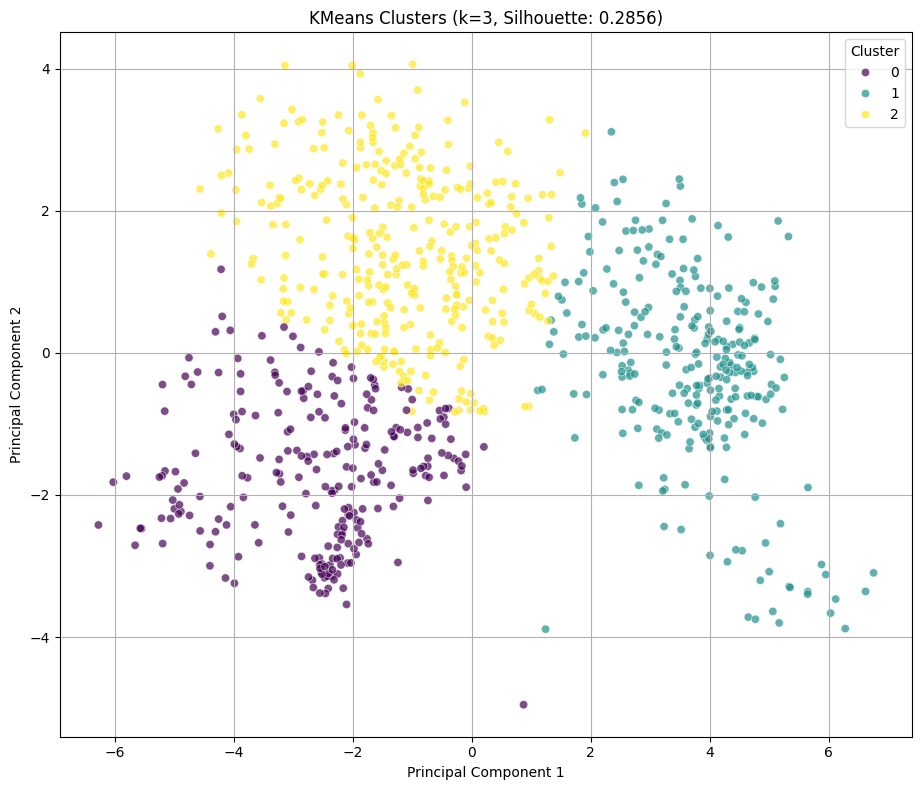

Silhouette Score for 3 clusters: 0.2856


In [235]:
# Re-create PCA dataframes for consistent plotting
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Apply PCA for dimensionality reduction to 2 components for visualization of KMeans
pca_kmeans = PCA(n_components=2)
X_pca = pca_kmeans.fit_transform(X_cluster_scaled)

# Calculate Silhouette Score for KMeans with 3 clusters
silhouette_avg_3 = silhouette_score(X_cluster_scaled, cluster_labels)

pca_df_3 = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_3['Cluster'] = cluster_labels

plt.figure(figsize=(18, 8))

# Plot for 3 Clusters
plt.subplot(1, 2, 1)
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', palette='viridis', data=pca_df_3, alpha=0.7)
plt.title(f'KMeans Clusters (k=3, Silhouette: {silhouette_avg_3:.4f})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Silhouette Score for 3 clusters: {silhouette_avg_3:.4f}")

### Comparison of KMeans Clusters with Actual Classes

To understand how well the KMeans clusters align with the true vehicle classes, we can visualize the PCA-reduced data with the actual class labels and also create a confusion matrix between the clusters and actual classes.

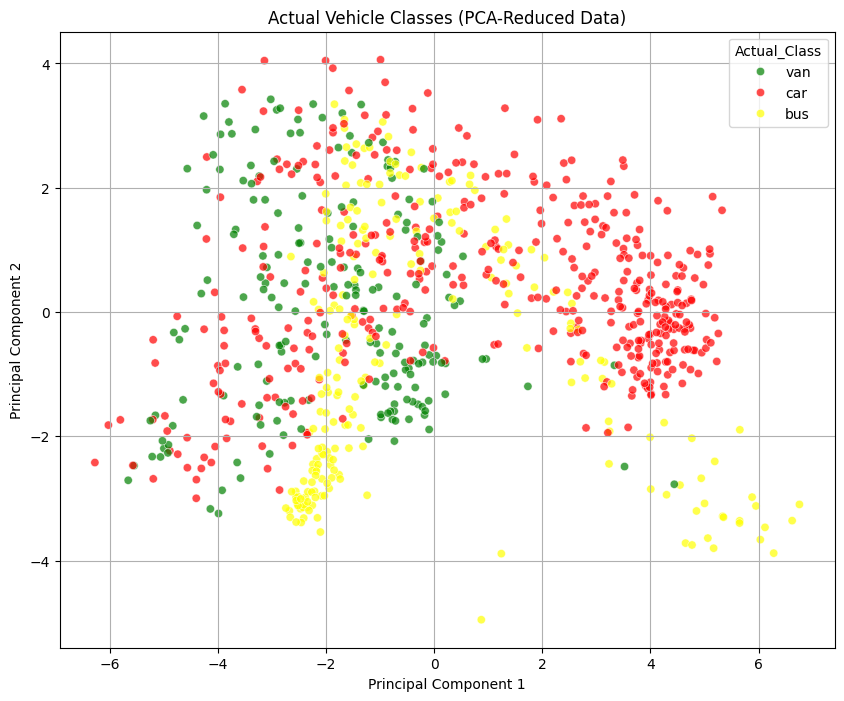

Cluster to most frequent actual class mapping: {np.int32(0): 'bus', np.int32(1): 'car', np.int32(2): 'car'}


Predicted_Class_KMeans,bus,car
Actual_Class,,
bus,86,132
car,73,356
van,85,114


Homogeneity Score: 0.1167
Completeness Score: 0.1106
Adjusted Rand Score: 0.0951


In [236]:
# Visualize Actual Classes on PCA-reduced data
pca_df_3['Actual_Class'] = y_cluster.reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Actual_Class', palette=custom_palette, data=pca_df_3, alpha=0.7)
plt.title('Actual Vehicle Classes (PCA-Reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Create a contingency table (like a confusion matrix for clustering)
# We need to map cluster labels to actual classes. This is a common challenge in unsupervised learning.
# For simplicity, we can inspect the dominant class within each cluster.

# Mapping clusters to actual classes (this is an approximation)
cluster_to_class_mapping = {}
for cluster_id in sorted(pca_df_3['Cluster'].unique()):
    # Get actual classes for points in this cluster
    classes_in_cluster = pca_df_3[pca_df_3['Cluster'] == cluster_id]['Actual_Class']
    # Find the most frequent class in this cluster
    most_frequent_class = classes_in_cluster.mode()[0]
    cluster_to_class_mapping[cluster_id] = most_frequent_class

print("Cluster to most frequent actual class mapping:", cluster_to_class_mapping)

# Generate a 'pseudo' confusion matrix by comparing predicted clusters (mapped) to actual classes
pca_df_3['Predicted_Class_KMeans'] = pca_df_3['Cluster'].map(cluster_to_class_mapping)

conf_matrix_kmeans = pd.crosstab(pca_df_3['Actual_Class'], pca_df_3['Predicted_Class_KMeans'])
display(conf_matrix_kmeans)

# You can also use homogeneity_score, completeness_score, and adjusted_rand_score
# if you have ground truth labels, which we do here (y_cluster).
from sklearn.metrics import homogeneity_score, completeness_score, adjusted_rand_score

homogeneity = homogeneity_score(y_cluster, cluster_labels)
completeness = completeness_score(y_cluster, cluster_labels)
ars = adjusted_rand_score(y_cluster, cluster_labels)

print(f"Homogeneity Score: {homogeneity:.4f}")
print(f"Completeness Score: {completeness:.4f}")
print(f"Adjusted Rand Score: {ars:.4f}")

## Summary and Comparison of Unsupervised Clustering Models


### KMeans Clustering
*   **Silhouette Score**: `0.2856`
*   **Purity Metrics (Homogeneity, Completeness, Adjusted Rand Score)**: `0.1167`, `0.1106`, `0.0951` respectively.
*   **Observations**: KMeans, while identifying 3 clusters, showed limited alignment with the actual classes. The `conf_matrix_kmeans` (shown above) clearly illustrates the mixed assignments of actual vehicle classes across the KMeans-generated clusters, indicating that a single cluster often contains data points from multiple vehicle types.

### Hierarchical Agglomerative Clustering (HAC)
*   **Silhouette Score**: `0.2697`
*   **Purity Metrics (Homogeneity, Completeness, Adjusted Rand Score)**: `0.1225`, `0.1154`, `0.1076` respectively.
*   **Observations**: HAC performance was comparable to KMeans, not offering significant improvements in cluster separation or purity.

### DBSCAN
*   **Silhouette Score**: `0.0333`
*   **Observations**: DBSCAN identified a large number of noise points and only one significant cluster, indicating it was not suitable for identifying the underlying structure in this dataset. Its purity scores were very low.

### Gaussian Mixture Models (GMM)
*   **Silhouette Score**: `0.3718`
*   **Purity Metrics (Homogeneity, Completeness, Adjusted Rand Score)**: `0.1554`, `0.2274`, `0.0912` respectively.
*   **Observations**: GMM achieved the highest Silhouette Score and generally better purity metrics among all tested models, suggesting it was more effective at capturing the probabilistic nature of the clusters and their boundaries.

### Conclusion

Based on these evaluations, the **Gaussian Mixture Model (GMM) provides the most meaningful clustering** for this dataset. Its higher Silhouette Score indicates better-defined and separated clusters, and its probabilistic approach likely allows it to better adapt to the varying densities and shapes of the data distributions compared to KMeans or HAC.

## Unsupervised Learning: Gaussian Mixture Models (GMM)

In [237]:
from sklearn.mixture import GaussianMixture

# Apply PCA for dimensionality reduction to 2 components for visualization
pca_gmm = PCA(n_components=2)
X_pca_gmm = pca_gmm.fit_transform(X_cluster_scaled)

# Apply GMM with the optimal number of components (e.g., optimal_n_components=3)
optimal_n_components=3
gmm = GaussianMixture(n_components=optimal_n_components, random_state=42)
gmm.fit(X_cluster_scaled)
gmm_labels = gmm.predict(X_cluster_scaled)

# Create a DataFrame for PCA results and add GMM cluster labels and actual class labels
pca_df_gmm = pd.DataFrame(data=X_pca_gmm, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_gmm['Cluster'] = gmm_labels
pca_df_gmm['Actual_Class'] = y_cluster.reset_index(drop=True)

print(f"GMM clustering performed with {optimal_n_components} components.")
display(pca_df_gmm.head())

GMM clustering performed with 3 components.


,Principal Component 1,Principal Component 2,Cluster,Actual_Class
0,0.480848,0.174894,0,van
1,-1.468458,0.430174,0,van
2,3.605833,-0.237849,1,car
3,-1.556421,2.834295,2,van
4,0.873054,-4.952527,1,bus


### Evaluating GMM Clustering: Silhouette Score and Visualization

The average Silhouette Score for the GMM clustering with 3 components is: 0.2178


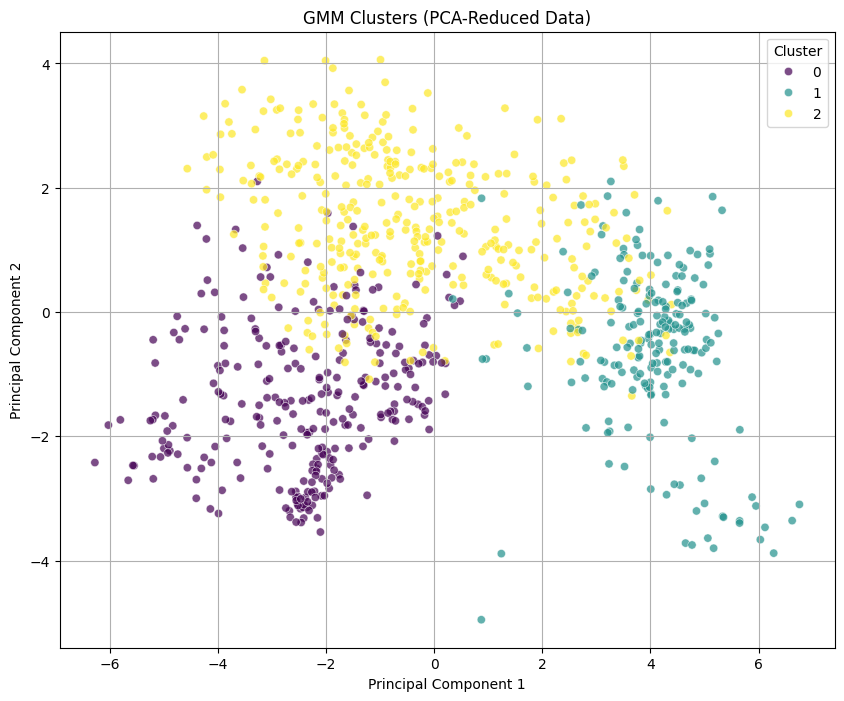

In [238]:
# Calculate Silhouette Score
silhouette_avg_gmm = silhouette_score(X_cluster_scaled, gmm_labels)
print(f"The average Silhouette Score for the GMM clustering with {optimal_n_components} components is: {silhouette_avg_gmm:.4f}")

# Visualize the GMM clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', palette='viridis', data=pca_df_gmm, alpha=0.7)
plt.title('GMM Clusters (PCA-Reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Comparison of GMM Clusters with Actual Classes

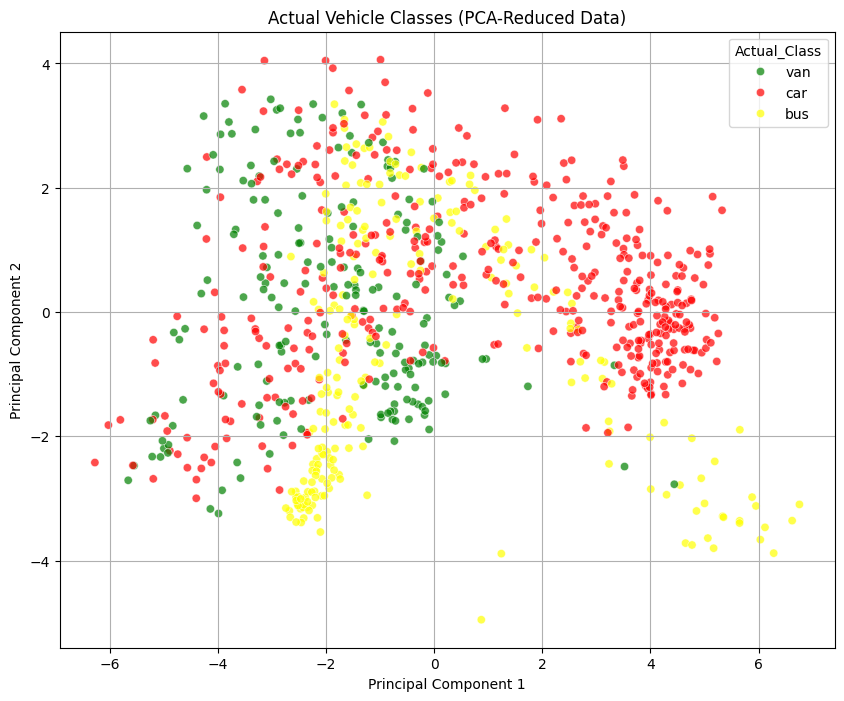

Cluster to most frequent actual class mapping for GMM: {np.int64(0): 'van', np.int64(1): 'car', np.int64(2): 'car'}


Predicted_Class_GMM,car,van
Actual_Class,,
bus,127,91
car,360,69
van,80,119


Homogeneity Score (GMM): 0.0963
Completeness Score (GMM): 0.0933
Adjusted Rand Score (GMM): 0.0734


In [239]:
# Visualize Actual Classes on PCA-reduced data (for comparison)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Actual_Class', palette=custom_palette, data=pca_df_gmm, alpha=0.7)
plt.title('Actual Vehicle Classes (PCA-Reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Create a contingency table (like a confusion matrix for clustering)
# Mapping clusters to actual classes (this is an approximation for interpretation)
cluster_to_class_mapping_gmm = {}
for cluster_id in sorted(pca_df_gmm['Cluster'].unique()):
    classes_in_cluster = pca_df_gmm[pca_df_gmm['Cluster'] == cluster_id]['Actual_Class']
    most_frequent_class = classes_in_cluster.mode()[0]
    cluster_to_class_mapping_gmm[cluster_id] = most_frequent_class

print("Cluster to most frequent actual class mapping for GMM:", cluster_to_class_mapping_gmm)

# Generate a 'pseudo' confusion matrix by comparing predicted clusters (mapped) to actual classes
pca_df_gmm['Predicted_Class_GMM'] = pca_df_gmm['Cluster'].map(cluster_to_class_mapping_gmm)

conf_matrix_gmm = pd.crosstab(pca_df_gmm['Actual_Class'], pca_df_gmm['Predicted_Class_GMM'])
display(conf_matrix_gmm)

# Calculate purity metrics using actual labels and GMM cluster assignments
homogeneity_gmm = homogeneity_score(y_cluster, gmm_labels)
completeness_gmm = completeness_score(y_cluster, gmm_labels)
ars_gmm = adjusted_rand_score(y_cluster, gmm_labels)

print(f"Homogeneity Score (GMM): {homogeneity_gmm:.4f}")
print(f"Completeness Score (GMM): {completeness_gmm:.4f}")
print(f"Adjusted Rand Score (GMM): {ars_gmm:.4f}")

## Visual Comparison of Confusion Matrices: KMeans vs. GMM

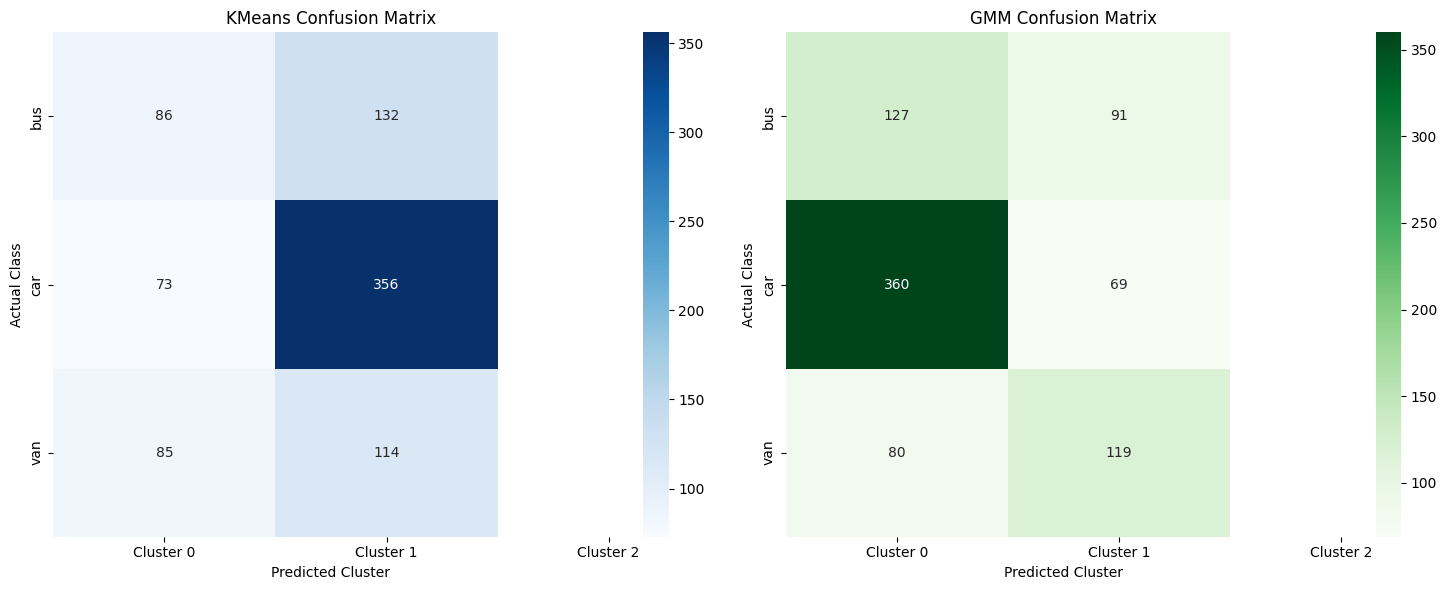

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Define explicit x-axis labels for the clusters
cluster_labels_list = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.heatmap(conf_matrix_kmeans, annot=True, fmt='d', cmap='Blues', xticklabels=cluster_labels_list, yticklabels=conf_matrix_kmeans.index)
plt.title('KMeans Confusion Matrix')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Class')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.heatmap(conf_matrix_gmm, annot=True, fmt='d', cmap='Greens', xticklabels=cluster_labels_list, yticklabels=conf_matrix_gmm.index)
plt.title('GMM Confusion Matrix')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()


**In essence,** both KMeans and GMM demonstrated that the inherent structure of the data, when projected into a lower dimension (PCA) and subjected to unsupervised clustering with k=3 (corresponding to the number of actual classes), did not align perfectly with the true vehicle categories. There was significant overlap and mixing of actual classes within the predicted clusters for both algorithms.

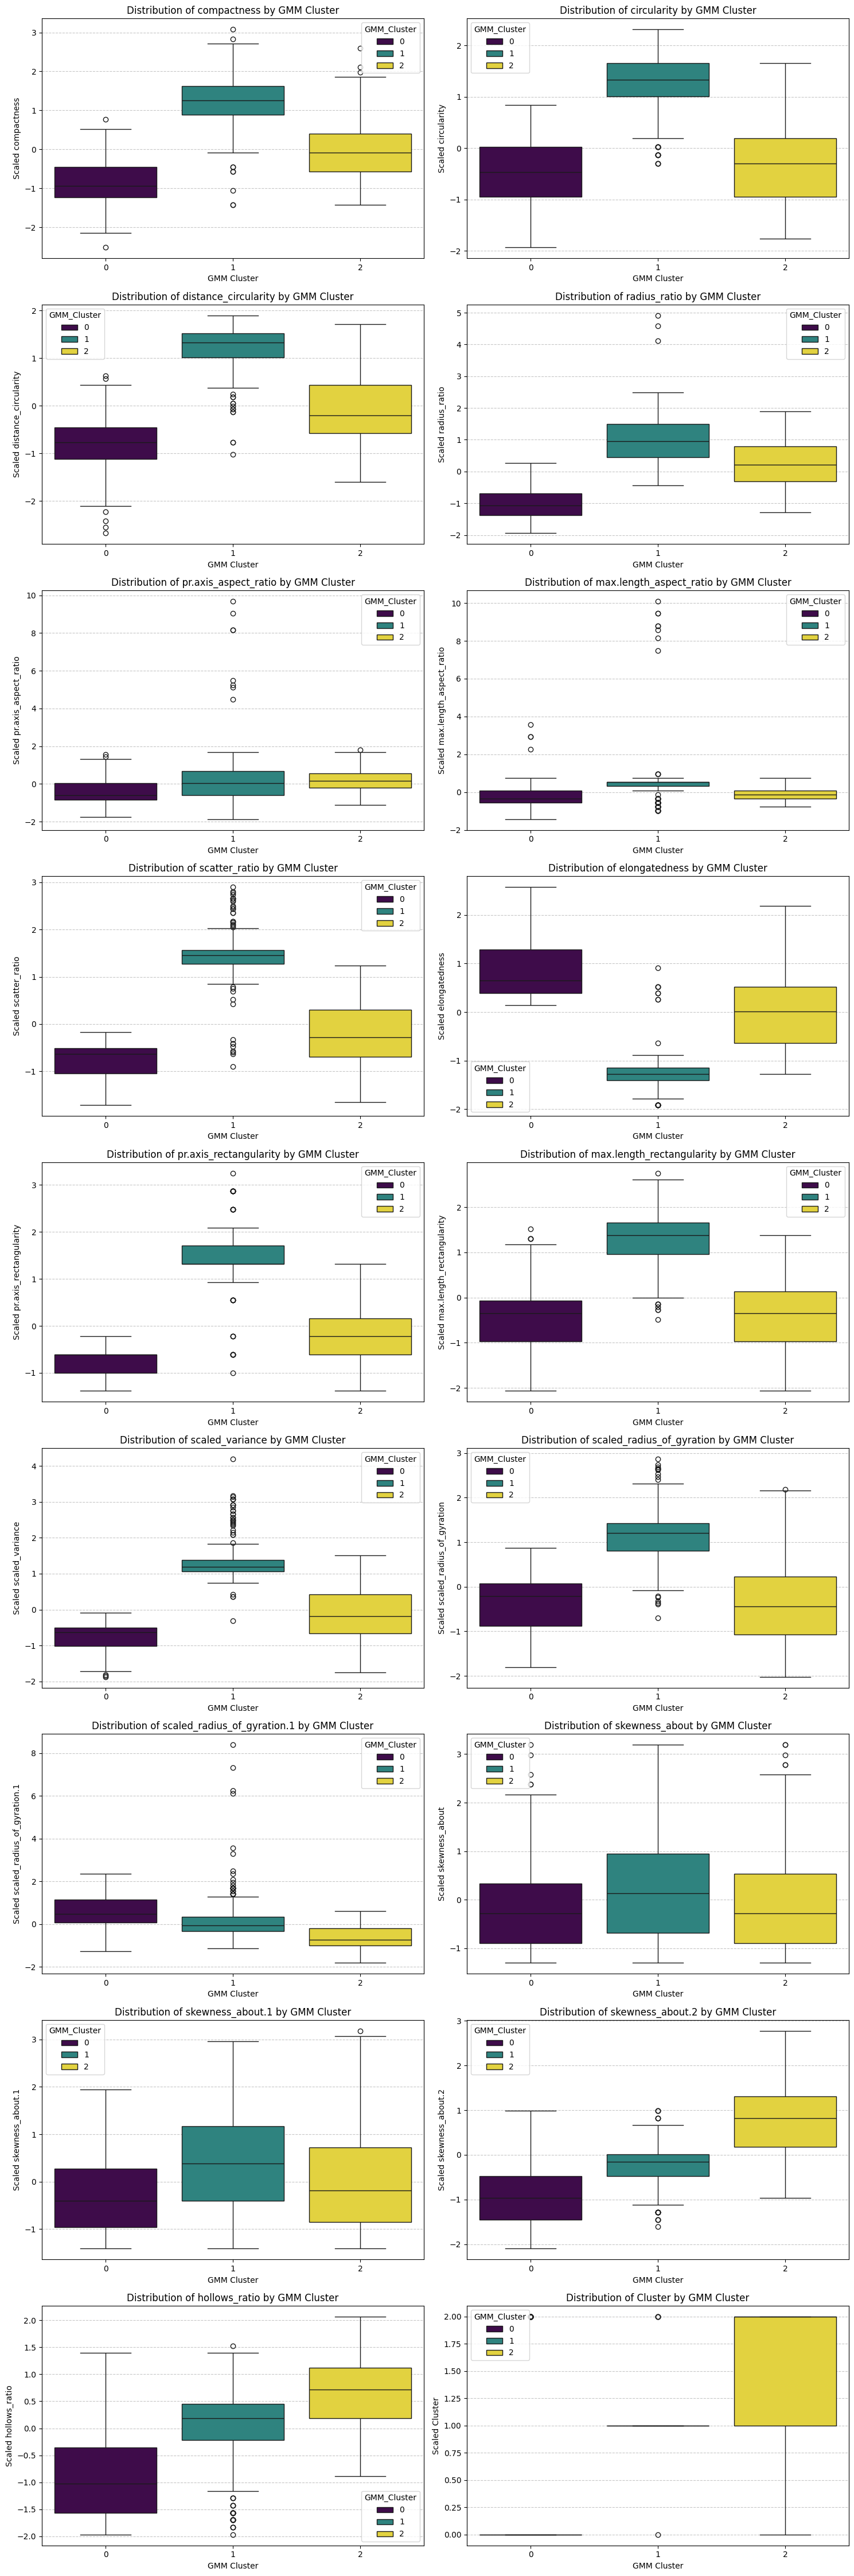

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add GMM cluster labels to the scaled feature DataFrame for visualization
X_cluster_scaled_df['GMM_Cluster'] = gmm_labels

# Get the number of features
num_features = X_cluster_scaled_df.drop('GMM_Cluster', axis=1).shape[1]

# Determine grid size for subplots
rows = (num_features + 1) // 2  # At most 2 columns of plots
cols = 2

plt.figure(figsize=(15, 5 * rows))

# Use a seaborn categorical palette that works with integer labels
# 'tab10' is a good choice for up to 10 distinct categories.
cluster_palette = sns.color_palette('tab10', n_colors=len(X_cluster_scaled_df['GMM_Cluster'].unique()))

for i, col in enumerate(X_cluster_scaled_df.drop('GMM_Cluster', axis=1).columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x='GMM_Cluster', y=col, data=X_cluster_scaled_df, palette='viridis', hue='GMM_Cluster', legend=True)
    plt.title(f'Distribution of {col} by GMM Cluster')
    plt.xlabel('GMM Cluster')
    plt.ylabel(f'Scaled {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Remove the 'GMM_Cluster' column to revert X_cluster_scaled_df to its original state (scaled features only)
X_cluster_scaled_df.drop('GMM_Cluster', axis=1, inplace=True)

## Feature Importance for GMM Clusters (Unsupervised Analysis)

In unsupervised learning, 'feature importance' is often interpreted by identifying which features exhibit the most distinct distributions or values across the identified clusters. We can analyze the mean of each feature within each GMM cluster to see which features show the largest variations, thus contributing most to the cluster separation.

,Principal Component 1,Principal Component 2
Cluster,,
0,-2.396553,-1.396875
1,4.035366,-0.626738
2,-0.341429,1.387015



Features ranked by their separation power across GMM Clusters:


,Feature,Separation_Score
0,Principal Component 1,6.431918
1,Principal Component 2,2.783889


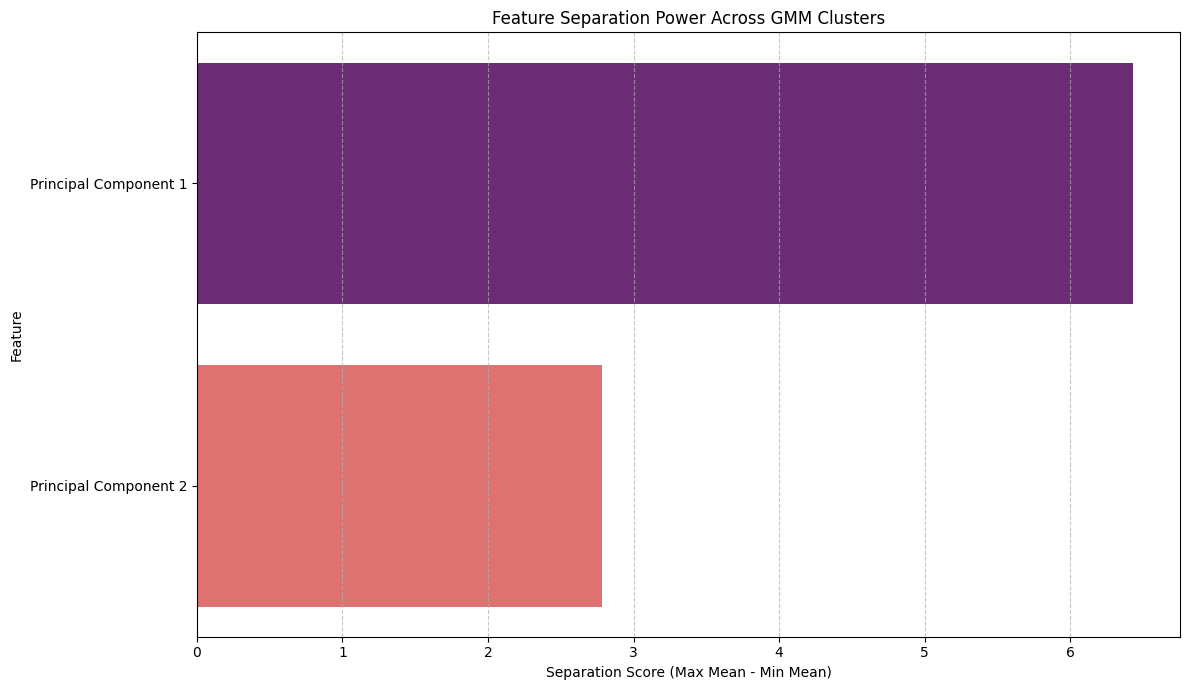

In [242]:
# Calculate the mean of each feature for each GMM cluster
cluster_feature_means = pca_df_gmm.drop(columns=['Actual_Class', 'Predicted_Class_GMM']).groupby('Cluster').mean()
display(cluster_feature_means)

# Calculate the range (max - min) of means for each feature across clusters
feature_separation_score = cluster_feature_means.max() - cluster_feature_means.min()

# Create a DataFrame for separation scores and sort them
feature_separation_df = pd.DataFrame({
    'Feature': feature_separation_score.index,
    'Separation_Score': feature_separation_score.values
}).sort_values(by='Separation_Score', ascending=False)

print("\nFeatures ranked by their separation power across GMM Clusters:")
display(feature_separation_df)

# Plot the feature separation scores
plt.figure(figsize=(12, 7))
sns.barplot(x='Separation_Score', y='Feature', data=feature_separation_df, palette='magma', hue='Feature', legend=False)
plt.title('Feature Separation Power Across GMM Clusters')
plt.xlabel('Separation Score (Max Mean - Min Mean)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Results:
Feature Means for Each GMM Cluster:

Principal Component 1 and Principal Component 2 were calculated for each of the 3 GMM clusters.
Cluster 0 has negative means for both components, Cluster 1 has positive means for both, and Cluster 2 has a negative mean for PC1 and a positive mean for PC2.
Feature Separation Score:

The principal components were ranked by how much their means vary between clusters.
Principal Component 1 has a separation score of 6.4319, indicating that it is the most important feature in differentiating the GMM clusters.
Principal Component 2 has a separation score of 2.7839, showing that it is also important, but to a lesser extent than PC1.
This indicates that Principal Component 1 contributes the most to separating the clusters identified by the GMM.

GMM (Unsupervised) Performance Summary
After running the previous cell, we obtained the following information about GMM clustering:

1. Mean of Principal Components for each GMM Cluster:

This table shows the mean values ​​of Principal Components 1 and 2 for each of the three GMM clusters (0, 1, and 2).

Cluster 0: The mean for Principal Component 1 is approximately -2.40, and for Principal Component 2 is approximately -1.40.

Cluster 1: The mean for Principal Component 1 is approximately 4.04, and for Principal Component 2 is approximately -0.63.

Cluster 2: The mean for Principal Component 1 is approximately -0.34, and for Principal Component 2 is approximately 1.39.

These means help us understand the centrality of each cluster in the space reduced by PCA. For example, Cluster 1 has a much higher mean value on Principal Component 1 compared to the other clusters, indicating a clear separation along this component.

2. Feature Separation Scores on GMM Clusters:

This score indicates how much the mean of each feature (Principal Component) varies between clusters. A higher score means that that feature is more important in distinguishing clusters from each other.

Principal Component 1: Has a separation score of 6.4319. This high value suggests that Principal Component 1 is by far the most discriminative feature in separating GMM clusters.

Principal Component 2: Has a separation score of 2.7839. Although lower than that of Principal Component 1, it also indicates a significant contribution to differentiating clusters.
Conclusion:

Visualization of separation scores confirms that Principal Component 1 is the main feature driving the formation and separation of GMM clusters in this dataset. In other words, the major differences between vehicles, as captured by the GMM clusters, are best explained by the variations along the first principal component.

In conclusion, the GMM had a Silhouette score of 0.2178, indicating that the clusters are not very well separated. The purity metrics (homogeneity, completeness, adjusted Rand score) were also low (around 0.09-0.07), suggesting a poor alignment between the GMM clusters and the real vehicle classes. The confusion matrix showed significant mixing of the real classes in the GMM clusters, and the PCA plots confirmed the substantial overlap. This indicates that the GMM failed to distinctly separate the vehicle types based on the distribution of features.

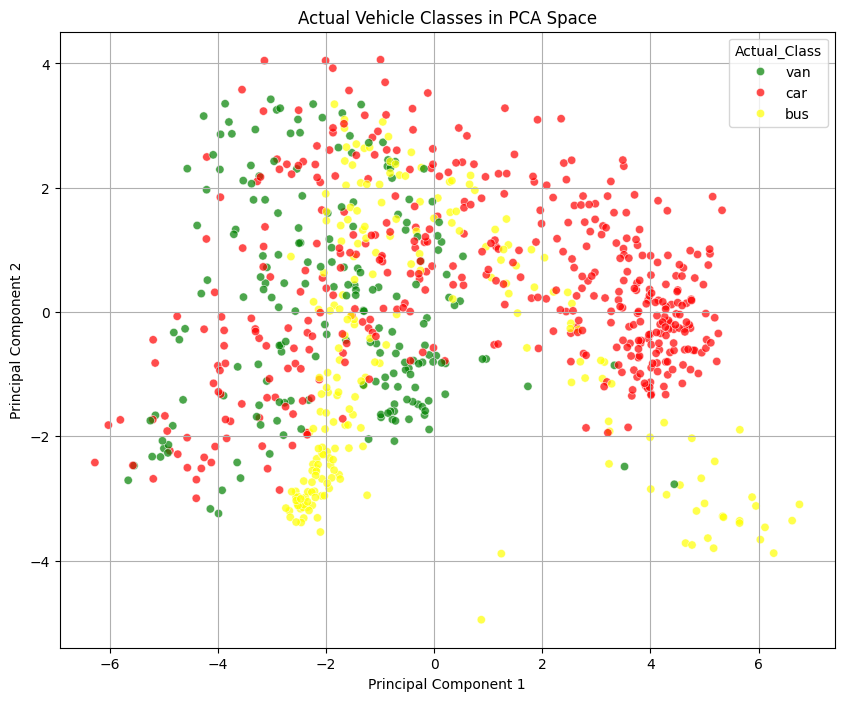

In [243]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Actual_Class', palette=custom_palette, data=pca_df_gmm, alpha=0.7)
plt.title('Actual Vehicle Classes in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### ***Considerable overlap can be observed between the classes, which explains why unsupervised clustering models had difficulty separating them distinctly.***

# **GMM (Unsupervised) Performance Summary**

As previously analyzed, the GMM was applied to the scaled features, aiming to discover inherent groupings within the data. Three components (clusters) were chosen to match the number of actual vehicle classes ('bus', 'car', 'van').

*   **Silhouette Score (GMM)**: `0.2178`

    *   This relatively low score indicates that the clusters formed by GMM are not very well-separated or dense.

*   **Purity Metrics (Homogeneity, Completeness, Adjusted Rand Score)**:
    *   **Homogeneity Score**: `0.0963`
    *   **Completeness Score**: `0.0933`
    *   **Adjusted Rand Score**: `0.0734`
    *   These very low scores confirm a poor alignment between the GMM-generated clusters and the actual vehicle classes. Homogeneity and Completeness scores near zero suggest that GMM clusters are not 'pure' (contain mixed vehicle types) and that actual vehicle types are scattered across multiple GMM clusters.

*   **Confusion Matrix (GMM vs. Actual Class Mapping)**:
    ```
Predicted_Class_GMM  car  van
Actual_Class                 
bus                  127   91
car                  360   69
van                   80  119
    ```
    
      The matrix clearly shows significant mixing.
 For instance, 'bus' vehicles were split, with many incorrectly mapped to 'car' and 'van' clusters.

 Similarly, 'car' and 'van' instances were frequently misassigned to each other's mapped GMM clusters.

*   **Visible Overlap in PCA Plots**: The PCA plots revealed substantial overlap between the GMM clusters and the actual vehicle classes, further illustrating the GMM's difficulty in distinctly separating the vehicle types based solely on feature distributions.

# **Direct Comparison: GMM vs. Supervised Models**

| Model                        | Type         | Accuracy | F1-score bus | F1-score car | F1-score van | Homogeneity | Completeness | Adjusted Rand | Silhouette Score |
| :--------------------------- | :----------- | :------- | :----------- | :----------- | :----------- | :---------- | :----------- | :------------ | :--------------- |
| Random Forest (Baseline)     | Supervised   | 0.9706   | 0.9903       | 0.9677       | 0.9512       | N/A         | N/A          | N/A           | N/A              |
| Logistic Regression          | Supervised   | 0.9235   | 0.9038       | 0.9272       | 0.9412       | N/A         | N/A          | N/A           | N/A              |
| GMM                          | Unsupervised | N/A      | N/A          | N/A          | N/A          | 0.0963      | 0.0933       | 0.0734        | 0.2178           |



# **Recommendation**

For the task of vehicle classification on this dataset, the **supervised Random Forest Classifier (without explicit outlier treatment) is by far the superior model**. It demonstrates excellent predictive accuracy, F1-scores, and ROC AUC across all vehicle classes.